<a href="https://colab.research.google.com/github/shatha-marzuq/DATA-s/blob/main/Cleaning_%26_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Cleaning & Preprocessing**

Import libraries and read the original CSV file, then display the general shape of the dataset.

In [ ]:
import pandas as pd
import numpy as np
import re
df = pd.read_csv('master_saudi_health_impact_20260225_221656.csv')
print( df.shape)
print(df.head())

(3713, 27)
                author_nickname  \
0             مركز سجية للتأهيل   
1                  رائد بن حسين   
2                       hasnxii   
3  الجوهره العجاجي Psychologist   
4                       mira.ot   

                                         description     likes  comments  \
0  ⁨\tالوعي بالصحة النفسية مهم .. مما له آثار على...    1591.0      76.0   
1  #رائد_بن_حسين #اكسبلورexplore #explore #اكسبلو...  277200.0   11800.0   
2  83% من السعوديين الذين شُخصوا باضطرابات نفسية ...    2323.0     366.0   
3  Replying to @Muhammad #وعي #صحة_نفسية #علم_الن...   35300.0     763.0   
4  ‎#السعوديه #ابودكاست_الثامنه #بودكاست #خليجي26...   60000.0    1545.0   

    shares      views        date            search_query platform video_id  \
0    599.0    84100.0  2025-10-11  الصحة النفسية السعودية   TikTok      NaN   
1  92200.0  7300000.0  2025-02-19  الصحة النفسية السعودية   TikTok      NaN   
2    989.0   197500.0  2022-10-10  الصحة النفسية السعودية   TikTok      NaN   
3   4

In [ ]:
tiktok  = df[df['platform'] == 'TikTok'].copy().reset_index(drop=True)
youtube = df[df['platform'].isna()].copy().reset_index(drop=True)

print(f"TikTok:  {len(tiktok)} Row")
print(f"YouTube: {len(youtube)} Row")

TikTok:  377 Row
YouTube: 3336 Row


In [ ]:
# TikTok
tiktok = tiktok[[
    'author_nickname',
    'description',
    'likes',
    'comments',
    'shares',
    'views',
    'date',
    'search_query'
]].copy()
tiktok['platform'] = 'TikTok'

# YouTube
youtube = youtube[[
    'channel_title',
    'title',
    'description',
    'view_count',
    'like_count',
    'comment_count',
    'subscriber_count',
    'influencer_tier',
    'published_at',
    'duration',
    'total_views',
    'video_count',
    'engagement_rate',
    'search_query'
]].copy()
youtube['platform'] = 'YouTube'

print("Colums TikTok:", tiktok.columns.tolist())
print("Colums YouTube:", youtube.columns.tolist())

Colums TikTok: ['author_nickname', 'description', 'likes', 'comments', 'shares', 'views', 'date', 'search_query', 'platform']
Colums YouTube: ['channel_title', 'title', 'description', 'view_count', 'like_count', 'comment_count', 'subscriber_count', 'influencer_tier', 'published_at', 'duration', 'total_views', 'video_count', 'engagement_rate', 'search_query', 'platform']


Convert columns to correct types (dates, numbers) and parse YouTube video duration into minutes.


In [ ]:
# ── TikTok ──────────────────────────────
tiktok['date'] = pd.to_datetime(tiktok['date'], errors='coerce').dt.date

for col in ['likes', 'comments', 'shares', 'views']:
    tiktok[col] = pd.to_numeric(tiktok[col], errors='coerce')


# ── YouTube ─────────────────────────────
youtube['published_at'] = pd.to_datetime(youtube['published_at'], errors='coerce').dt.date

for col in ['view_count', 'like_count', 'comment_count',
            'subscriber_count', 'total_views', 'video_count', 'engagement_rate']:
    youtube[col] = pd.to_numeric(youtube[col], errors='coerce')

def parse_duration(d):
    if pd.isna(d): return np.nan
    h = re.search(r'(\d+)H', str(d))
    m = re.search(r'(\d+)M', str(d))
    s = re.search(r'(\d+)S', str(d))
    total_seconds = 0
    if h: total_seconds += int(h.group(1)) * 3600
    if m: total_seconds += int(m.group(1)) * 60
    if s: total_seconds += int(s.group(1))
    return total_seconds

youtube['duration_seconds'] = youtube['duration'].apply(parse_duration)
youtube['duration_minutes'] = (youtube['duration_seconds'] / 60).round(2)
youtube.drop(columns=['duration'], inplace=True)

print(tiktok.dtypes)
print(youtube[['view_count', 'published_at', 'duration_minutes']].dtypes)
print(f"\n Example: PT6M47S = {parse_duration('PT6M47S')} secands")

author_nickname     object
description         object
likes              float64
comments           float64
shares             float64
views              float64
date                object
search_query        object
platform            object
dtype: object
view_count          float64
published_at         object
duration_minutes    float64
dtype: object

 Example: PT6M47S = 407 secands


Fill missing values with appropriate defaults and drop rows missing critical fields.


In [ ]:
# ── TikTok ──────────────────────────────
print("TikTok missing:\n", tiktok.isnull().sum())

tiktok['description'] = tiktok['description'].fillna('لا يوجد وصف')

for col in ['likes', 'comments', 'shares']:
    tiktok[col] = tiktok[col].fillna(0)

tiktok.dropna(subset=['views'], inplace=True)

# ── YouTube ─────────────────────────────
print("\nYouTube missing:\n", youtube.isnull().sum())

youtube['description'] = youtube['description'].fillna('لا يوجد وصف')

for col in ['like_count', 'comment_count']:
    youtube[col] = youtube[col].fillna(0)

youtube.dropna(subset=['view_count'], inplace=True)

print("\n after preprocessing")
print("TikTok missing:\n", tiktok.isnull().sum())
print("\nYouTube missing:\n", youtube.isnull().sum())

TikTok missing:
 author_nickname    1
description        5
likes              0
comments           0
shares             0
views              0
date               0
search_query       0
platform           0
dtype: int64

YouTube missing:
 channel_title          0
title                  0
description         1126
view_count             0
like_count             0
comment_count          0
subscriber_count       0
influencer_tier        0
published_at           0
total_views            0
video_count            0
engagement_rate        0
search_query           0
platform               0
duration_seconds       0
duration_minutes       0
dtype: int64

 after preprocessing
TikTok missing:
 author_nickname    1
description        0
likes              0
comments           0
shares             0
views              0
date               0
search_query       0
platform           0
dtype: int64

YouTube missing:
 channel_title       0
title               0
description         0
view_count          0
l

Remove hashtags, URLs, emojis, and special characters from description columns.


In [ ]:
def clean_arabic_text(text):
    if pd.isna(text): return text
    text = re.sub(r'[^\w\s\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF.,!?؟،]', ' ', text)
    text = re.sub(r'#\S+', '', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

tiktok['description_clean']  = tiktok['description'].apply(clean_arabic_text)
youtube['description_clean'] = youtube['description'].apply(clean_arabic_text)
youtube['title_clean']       = youtube['title'].apply(clean_arabic_text)

tiktok['author_nickname'] = tiktok['author_nickname'].str.strip()
youtube['channel_title']  = youtube['channel_title'].str.strip()


Calculate Engagement Rate, extract year and month from date columns, and categorize video duration.


In [ ]:
# ── TikTok ──────────────────────────────

# Engagement Rate = (likes + comments + shares) / views × 100
tiktok['engagement_rate'] = (
    (tiktok['likes'] + tiktok['comments'] + tiktok['shares'])
    / tiktok['views'] * 100
).round(2)

tiktok['date'] = pd.to_datetime(tiktok['date'], errors='coerce')
tiktok['year']  = tiktok['date'].dt.year
tiktok['month'] = tiktok['date'].dt.month
tiktok['date']  = tiktok['date'].dt.date

# ── YouTube ─────────────────────────────

youtube['published_at'] = pd.to_datetime(youtube['published_at'], errors='coerce')
youtube['year']  = youtube['published_at'].dt.year
youtube['month'] = youtube['published_at'].dt.month
youtube['published_at'] = youtube['published_at'].dt.date

# YouTube engagement_rate مضروبة بـ 100
youtube['engagement_rate'] = (youtube['engagement_rate'] * 100).round(2)

def categorize_duration(mins):
    if pd.isna(mins):  return 'Unknown'
    if mins <= 1:      return 'Short'
    if mins <= 5:      return 'Medium'
    if mins <= 20:     return 'Long'
    return 'Very Long'

youtube['duration_category'] = youtube['duration_minutes'].apply(categorize_duration)

print(tiktok[['views','likes','engagement_rate','year']].head())
print(youtube[['view_count','duration_minutes','duration_category']].head())

       views     likes  engagement_rate  year
0    84100.0    1591.0             2.69  2025
1  7300000.0  277200.0             5.22  2025
2   197500.0    2323.0             1.86  2022
3  1100000.0   35300.0             3.69  2023
4  2000000.0   60000.0             4.87  2025
   view_count  duration_minutes duration_category
0   4658900.0              0.27             Short
1       316.0              6.78              Long
2       403.0              1.30            Medium
3      2548.0             58.47         Very Long
4   3574036.0            126.97         Very Long


Assign influencer tiers to TikTok creators based on total views, and keep existing tiers for YouTube.


In [ ]:
creator_stats = (
    tiktok.groupby('author_nickname')['views']
    .sum()
    .reset_index()
    .rename(columns={'views': 'creator_total_views'})
)

def assign_tier(total_views):
    if total_views >= 10_000_000: return 'Mega Influencer'
    if total_views >= 1_000_000:  return 'Macro Influencer'
    if total_views >= 100_000:    return 'Micro Influencer'
    if total_views >= 10_000:     return 'Nano Influencer'
    return 'Regular Creator'

creator_stats['influencer_tier'] = creator_stats['creator_total_views'].apply(assign_tier)
if 'influencer_tier' in tiktok.columns:
    tiktok = tiktok.drop(columns=['influencer_tier'])

# الحين اعمل الـ merge
tiktok = tiktok.merge(
    creator_stats[['author_nickname', 'influencer_tier']],
    on='author_nickname',
    how='left'
)
print("TikTok influencer tier distribution:")
print(tiktok['influencer_tier'].value_counts())

print("\nYouTube influencer tier distribution:")
print(youtube['influencer_tier'].value_counts())

TikTok influencer tier distribution:
influencer_tier
Macro Influencer    105
Micro Influencer     99
Nano Influencer      92
Regular Creator      69
Mega Influencer      11
Name: count, dtype: int64

YouTube influencer tier distribution:
influencer_tier
Macro Influencer    989
Micro Influencer    728
Mega Influencer     678
Nano Influencer     574
Regular Creator     367
Name: count, dtype: int64


Merge TikTok and YouTube into a single unified DataFrame with consistent column names.


In [ ]:
# ══════════════════════════════════════════
# ══════════════════════════════════════════

# --- TikTok: DataFrame  ---
tiktok_unified = pd.DataFrame({
    'platform':          tiktok['platform'],
    'creator_name':      tiktok['author_nickname'],
    'content_title':     tiktok['description_clean'].str[:100],  # أول 100 حرف كعنوان
    'description':       tiktok['description'],
    'description_clean': tiktok['description_clean'],
    'views':             tiktok['views'],
    'likes':             tiktok['likes'],
    'comments':          tiktok['comments'],
    'shares':            tiktok['shares'],
    'engagement_rate':   tiktok['engagement_rate'],
    'published_date':    tiktok['date'],
    'year':              tiktok['year'],
    'month':             tiktok['month'],
    'influencer_tier':   tiktok['influencer_tier'],
    'search_query':      tiktok['search_query'],
    'subscriber_count':  np.nan,
    'duration_minutes':  np.nan,
    'duration_category': np.nan,       # Not in TikTok
})

# --- YouTube: DataFrame ---
youtube_unified = pd.DataFrame({
    'platform':          youtube['platform'],
    'creator_name':      youtube['channel_title'],
    'content_title':     youtube['title_clean'],
    'description':       youtube['description'],
    'description_clean': youtube['description_clean'],
    'views':             youtube['view_count'],
    'likes':             youtube['like_count'],
    'comments':          youtube['comment_count'],
    'shares':            np.nan,       # Not in YouTube
    'engagement_rate':   youtube['engagement_rate'],
    'published_date':    youtube['published_at'],
    'year':              youtube['year'],
    'month':             youtube['month'],
    'influencer_tier':   youtube['influencer_tier'],
    'search_query':      youtube['search_query'],
    'subscriber_count':  youtube['subscriber_count'],
    'duration_minutes':  youtube['duration_minutes'],
    'duration_category': youtube['duration_category'],
})

combined = pd.concat([tiktok_unified, youtube_unified], ignore_index=True)

print(f" TikTok row:  {len(tiktok_unified)}")
print(f" YouTube row: {len(youtube_unified)}")
print(f" Total:       {len(combined)}")
print(f"\n columns: {combined.columns.tolist()}")

 TikTok row:  377
 YouTube row: 3336
 Total:       3713

 columns: ['platform', 'creator_name', 'content_title', 'description', 'description_clean', 'views', 'likes', 'comments', 'shares', 'engagement_rate', 'published_date', 'year', 'month', 'influencer_tier', 'search_query', 'subscriber_count', 'duration_minutes', 'duration_category']


Check for missing values, review columns, and preview the combined dataset.


In [ ]:
display(combined.head(1000))

,platform,creator_name,content_title,description,description_clean,views,likes,comments,shares,engagement_rate,published_date,year,month,influencer_tier,search_query,subscriber_count,duration_minutes,duration_category
0,TikTok,مركز سجية للتأهيل,الوعي بالصحة النفسية مهم .. مما له آثار على تح...,⁨\tالوعي بالصحة النفسية مهم .. مما له آثار على...,الوعي بالصحة النفسية مهم .. مما له آثار على تح...,84100.0,1591.0,76.0,599.0,2.69,2025-10-11,2025,10,Nano Influencer,الصحة النفسية السعودية,NaN,NaN,NaN
1,TikTok,رائد بن حسين,رائد_بن_حسين اكسبلورexplore explore اكسبلور ال...,#رائد_بن_حسين #اكسبلورexplore #explore #اكسبلو...,رائد_بن_حسين اكسبلورexplore explore اكسبلور ال...,7300000.0,277200.0,11800.0,92200.0,5.22,2025-02-19,2025,2,Macro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN
2,TikTok,hasnxii,83 من السعوديين الذين شُخصوا باضطرابات نفسية ل...,83% من السعوديين الذين شُخصوا باضطرابات نفسية ...,83 من السعوديين الذين شُخصوا باضطرابات نفسية ل...,197500.0,2323.0,366.0,989.0,1.86,2022-10-10,2022,10,Micro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN
3,TikTok,الجوهره العجاجي Psychologist,Replying to Muhammad وعي صحة_نفسية علم_النفس ا...,Replying to @Muhammad #وعي #صحة_نفسية #علم_الن...,Replying to Muhammad وعي صحة_نفسية علم_النفس ا...,1100000.0,35300.0,763.0,4507.0,3.69,2023-07-06,2023,7,Macro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN
4,TikTok,mira.ot,السعوديه ابودكاست_الثامنه بودكاست خليجي26 بودك...,‎#السعوديه #ابودكاست_الثامنه #بودكاست #خليجي26...,السعوديه ابودكاست_الثامنه بودكاست خليجي26 بودك...,2000000.0,60000.0,1545.0,35800.0,4.87,2025-10-09,2025,10,Macro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,YouTube,كنوز المعرفة الإعلامية,فعاليات اليوم العالمي للصحة النفسية بـ مجمع إر...,تحذير|نسخك او تحميلك ل هذا المحتوى يعرض قناتك ...,تحذير نسخك او تحميلك ل هذا المحتوى يعرض قناتك ...,413.0,11.0,0.0,NaN,2.66,2022-11-02,2022,11,Micro Influencer,مبادرات الصحة النفسية المملكة,12500.0,74.80,Very Long
996,YouTube,قناة الإخبارية,مختص بتعزيز الصحة النفسية الكل يخاف من الشيخوخ...,للتواصل email ekhbariyatv@sbc.sa Website https...,للتواصل email ekhbariyatv sbc.sa Website Twitt...,633.0,4.0,1.0,NaN,0.79,2022-03-03,2022,3,Mega Influencer,مبادرات الصحة النفسية المملكة,1640000.0,7.72,Long
997,YouTube,مشاة الطائف,مشاركة فريق مشاة الطائف في تنظيم فعاليه المشي ...,مشاركة فريق مشاة الطائف في تنظيم فعاليه المشي ...,مشاركة فريق مشاة الطائف في تنظيم فعاليه المشي ...,90.0,0.0,0.0,NaN,0.00,2019-05-12,2019,5,Regular Creator,مبادرات الصحة النفسية المملكة,28.0,0.18,Short
998,YouTube,NUPCO - نوبكو,مبادرة للتوعية بالصحة النفسية نوبكو,بمناسبة #اليوم_العالمي_للصحة_النفسية ، ساهمت #...,بمناسبة اليوم_العالمي_للصحة_النفسية ، ساهمت نو...,157.0,1.0,0.0,NaN,0.64,2021-11-10,2021,11,Regular Creator,مبادرات الصحة النفسية المملكة,733.0,0.98,Short


In [ ]:
print(combined.isnull().sum())

platform                0
creator_name            1
content_title           0
description             0
description_clean       0
views                   0
likes                   0
comments                0
shares               3336
engagement_rate         0
published_date          0
year                    0
month                   0
influencer_tier         1
search_query            0
subscriber_count      377
duration_minutes      377
duration_category     377
dtype: int64


Apply an improved cleaning function to remove emojis, mentions, phone numbers, and control characters.


In [ ]:
import re

def clean_arabic_text(text):
    if pd.isna(text): return text

    #  الهاشتاق مع الكلمة (#الصحة_النفسية)
    text = re.sub(r'#\S+', '', text)

    #  الإيموجي
    text = re.sub(r'[\U00010000-\U0010ffff]', '', text)
    text = re.sub(r'[\U0001F300-\U0001F9FF]', '', text)

    #  الـ @ مع الاسم (@username)
    text = re.sub(r'@\S+', '', text)

    #  URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    #  أحرف التحكم الغريبة (زي اللي في أول النص)
    text = re.sub(r'[\u200f\u200e\u202a-\u202e\u2066-\u2069]', '', text)

    #  النقاط المتكررة
    text = re.sub(r'\.{2,}', '.', text)

    #  المسافات الزائدة
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# طبّق على combined
combined['description_clean'] = combined['description'].apply(clean_arabic_text)
combined['content_title']      = combined['content_title'].apply(clean_arabic_text)

# تحقق
print("After:")
print(combined['description_clean'].iloc[0])

After:
الوعي بالصحة النفسية مهم . مما له آثار على تحسين صحتنا النفسية و العقلية والعيش براحة وسلام أ.غالب ابوالفرج مرشح دكتوراه في علم النفس - جامعه كينغز كولدج لندن ، حاصل على ماجستير علم نفس ارشادي من جامعه بالتيمور الولايات المتحدة الأمريكية. خبرة ١٠ سنوات في التعامل مع الاضطرابات النفسية.


Drop the raw description column and rename the cleaned version for clarity.


In [ ]:
combined.drop(columns=['description', 'content_title'], inplace=True)
combined.rename(columns={
    'description_clean': 'description',
    'title_clean':       'content_title'
}, inplace=True)

print(combined.columns.tolist())

['platform', 'creator_name', 'description', 'views', 'likes', 'comments', 'shares', 'engagement_rate', 'published_date', 'year', 'month', 'influencer_tier', 'search_query', 'subscriber_count', 'duration_minutes', 'duration_category']


In [ ]:
combined['creator_name'] = combined['creator_name'].apply(clean_arabic_text)

# check
print(combined['creator_name'].head(10))

0               مركز سجية للتأهيل
1                    رائد بن حسين
2                         hasnxii
3    الجوهره العجاجي Psychologist
4                         mira.ot
5           Dr. Mohammad Alolayan
6                           jowre
7                      هبة الرياض
8                            MBC1
9                  روان | المدينة
Name: creator_name, dtype: object


In [ ]:
def clean_arabic_text(text):
    if pd.isna(text): return text

    text = re.sub(r'#\S+', '', text)

    text = re.sub(r'[\U00010000-\U0010ffff]', '', text)
    text = re.sub(r'[\U0001F300-\U0001F9FF]', '', text)
    text = re.sub(r'[\u2600-\u27BF]', '', text)
    text = re.sub(r'[\uFE00-\uFE0F]', '', text)

    text = re.sub(r'@\S+', '', text)

    text = re.sub(r'http\S+|www\.\S+', '', text)

    text = re.sub(r'[\u200f\u200e\u202a-\u202e\u2066-\u2069]', '', text)

    text = re.sub(r'_', ' ', text)

    text = re.sub(r'\.{2,}', '.', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

combined['description'] = combined['description'].apply(clean_arabic_text)

print(combined['description'].iloc[4])

In [ ]:
display(combined.head(500))

,platform,creator_name,description,views,likes,comments,shares,engagement_rate,published_date,year,month,influencer_tier,search_query,subscriber_count,duration_minutes,duration_category
0,TikTok,مركز سجية للتأهيل,الوعي بالصحة النفسية مهم . مما له آثار على تحس...,84100.0,1591.0,76.0,599.0,2.69,2025-10-11,2025,10,Nano Influencer,الصحة النفسية السعودية,NaN,NaN,NaN
1,TikTok,رائد بن حسين,,7300000.0,277200.0,11800.0,92200.0,5.22,2025-02-19,2025,2,Macro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN
2,TikTok,hasnxii,83% من السعوديين الذين شُخصوا باضطرابات نفسية ...,197500.0,2323.0,366.0,989.0,1.86,2022-10-10,2022,10,Micro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN
3,TikTok,الجوهره العجاجي Psychologist,Replying to,1100000.0,35300.0,763.0,4507.0,3.69,2023-07-06,2023,7,Macro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN
4,TikTok,mira.ot,,2000000.0,60000.0,1545.0,35800.0,4.87,2025-10-09,2025,10,Macro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,YouTube,إذاعة ثمانية,بودكاست فنجان مع د. عبدالله السبيعي |,377692.0,11233.0,274.0,NaN,3.05,2023-06-13,2023,6,Mega Influencer,صناع محتوى الصحة النفسية سعوديين,5170000.0,1.00,Short
496,YouTube,saudi _277,الله يحيكم بالنيابة عن صاحبة الحساب معكم منال ...,24447785.0,236712.0,15127.0,NaN,1.03,2022-04-08,2022,4,Macro Influencer,صناع محتوى الصحة النفسية سعوديين,917000.0,0.18,Short
497,YouTube,Stade Hayder | ملعب حيدر,لا يوجد وصف,7018876.0,0.0,303.0,NaN,0.00,2024-10-20,2024,10,Macro Influencer,صناع محتوى الصحة النفسية سعوديين,396000.0,0.83,Short
498,YouTube,Adnan Al ansari,لا يوجد وصف,12995375.0,259958.0,2421.0,NaN,2.02,2022-10-31,2022,10,Mega Influencer,صناع محتوى الصحة النفسية سعوديين,5450000.0,0.43,Short


Classify each post as Arabic, English, or Mixed based on character ratio in the description.


In [ ]:
def classify_language(text):
    if pd.isna(text): return 'unknown'

    arabic  = len(re.findall(r'[\u0600-\u06FF]', str(text)))
    english = len(re.findall(r'[a-zA-Z]', str(text)))

    if arabic == 0 and english == 0: return 'unknown'

    total = arabic + english
    arabic_ratio  = arabic  / total
    english_ratio = english / total

    if arabic_ratio >= 0.8:  return 'Arabic'
    if english_ratio >= 0.8: return 'English'
    return 'Mixed'

combined['language'] = combined['description'].apply(classify_language)

print(combined['language'].value_counts())


language
Arabic     2848
English     632
Mixed       124
unknown     109
Name: count, dtype: int64


In [ ]:
print(combined.columns.tolist())

['platform', 'creator_name', 'description', 'views', 'likes', 'comments', 'shares', 'engagement_rate', 'published_date', 'year', 'month', 'influencer_tier', 'search_query', 'subscriber_count', 'duration_minutes', 'duration_category', 'language']


In [ ]:
combined

,platform,creator_name,description,views,likes,comments,shares,engagement_rate,published_date,year,month,influencer_tier,search_query,subscriber_count,duration_minutes,duration_category,language
0,TikTok,مركز سجية للتأهيل,الوعي بالصحة النفسية مهم . مما له آثار على تحس...,84100.0,1591.0,76.0,599.0,2.69,2025-10-11,2025,10,Nano Influencer,الصحة النفسية السعودية,NaN,NaN,NaN,Arabic
1,TikTok,رائد بن حسين,,7300000.0,277200.0,11800.0,92200.0,5.22,2025-02-19,2025,2,Macro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN,unknown
2,TikTok,hasnxii,83% من السعوديين الذين شُخصوا باضطرابات نفسية ...,197500.0,2323.0,366.0,989.0,1.86,2022-10-10,2022,10,Micro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN,Arabic
3,TikTok,الجوهره العجاجي Psychologist,Replying to,1100000.0,35300.0,763.0,4507.0,3.69,2023-07-06,2023,7,Macro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN,English
4,TikTok,mira.ot,,2000000.0,60000.0,1545.0,35800.0,4.87,2025-10-09,2025,10,Macro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3708,YouTube,drop1281,لا يوجد وصف,954.0,3.0,0.0,NaN,0.31,2013-12-02,2013,12,Regular Creator,صحة نفسية كبار السن السعودية,22.0,2.80,Medium,Arabic
3709,YouTube,Hossam Mowafy-حسام موافي,الجلد,251669.0,7617.0,102.0,NaN,3.07,2024-12-24,2024,12,Macro Influencer,صحة نفسية كبار السن السعودية,243000.0,2.60,Medium,Arabic
3710,YouTube,أ.د. طارق الحبيب,أفضل طرق علاج فرط الحركة وتشتت الانتباه عند ال...,31070.0,830.0,52.0,NaN,2.84,2025-07-02,2025,7,Macro Influencer,صحة نفسية كبار السن السعودية,472000.0,1.40,Medium,Arabic
3711,YouTube,Heiam H,لا يوجد وصف,23158.0,84.0,24.0,NaN,0.47,2023-07-12,2023,7,Regular Creator,صحة نفسية كبار السن السعودية,38.0,0.27,Short,Arabic


In [ ]:
print("=== Missing Values ===")
print(combined.isnull().sum())

print("\n=== Columns ===")
print(combined.columns.tolist())

print("\n=== Shape ===")
print(combined.shape)

print("\n=== Sample ===")
display(combined.head(5))

=== Missing Values ===
platform                0
creator_name            1
description             0
views                   0
likes                   0
comments                0
shares               3336
engagement_rate         0
published_date          0
year                    0
month                   0
influencer_tier         1
search_query            0
subscriber_count      377
duration_minutes      377
duration_category     377
language                0
dtype: int64

=== Columns ===
['platform', 'creator_name', 'description', 'views', 'likes', 'comments', 'shares', 'engagement_rate', 'published_date', 'year', 'month', 'influencer_tier', 'search_query', 'subscriber_count', 'duration_minutes', 'duration_category', 'language']

=== Shape ===
(3713, 17)

=== Sample ===


,platform,creator_name,description,views,likes,comments,shares,engagement_rate,published_date,year,month,influencer_tier,search_query,subscriber_count,duration_minutes,duration_category,language
0,TikTok,مركز سجية للتأهيل,الوعي بالصحة النفسية مهم . مما له آثار على تحس...,84100.0,1591.0,76.0,599.0,2.69,2025-10-11,2025,10,Nano Influencer,الصحة النفسية السعودية,NaN,NaN,NaN,Arabic
1,TikTok,رائد بن حسين,,7300000.0,277200.0,11800.0,92200.0,5.22,2025-02-19,2025,2,Macro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN,unknown
2,TikTok,hasnxii,83% من السعوديين الذين شُخصوا باضطرابات نفسية ...,197500.0,2323.0,366.0,989.0,1.86,2022-10-10,2022,10,Micro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN,Arabic
3,TikTok,الجوهره العجاجي Psychologist,Replying to,1100000.0,35300.0,763.0,4507.0,3.69,2023-07-06,2023,7,Macro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN,English
4,TikTok,mira.ot,,2000000.0,60000.0,1545.0,35800.0,4.87,2025-10-09,2025,10,Macro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN,unknown


In [ ]:
import pandas as pd
import re
import glob

def remove_emojis(text):
    if pd.isna(text):
        return text
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002700-\U000027BF"
        u"\U0001F900-\U0001F9FF"
        u"\U00002500-\U00002BEF"
        u"\U0001FA00-\U0001FA6F"
        u"\U0001FA70-\U0001FAFF"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub('', text).strip()

master_files = glob.glob('master_saudi_health_impact_*.csv')
latest_file = sorted(master_files)[-1]
master_df = pd.read_csv(latest_file)
print(f" Loaded: {latest_file} ({len(master_df)} rows)")

text_columns = master_df.select_dtypes(include='object').columns
for col in text_columns:
    master_df[col] = master_df[col].apply(remove_emojis)

print(" Emojis removed from ALL text columns!")

master_df.to_csv(latest_file, index=False, encoding='utf-8-sig')
master_df.to_excel(latest_file.replace('.csv', '.xlsx'), index=False)
print(" File saved successfully!")

 Loaded: master_saudi_health_impact_20260225_221656.csv (3713 rows)
 Emojis removed from ALL text columns!
 File saved successfully!


In [ ]:
import re

def remove_emojis(text):
    if pd.isna(text): return text
    text = re.sub(r'[^\w\s\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF.,!?@#\-_()\[\]:]', '', str(text))
    return text.strip()

combined['creator_name'] = combined['creator_name'].apply(remove_emojis)

print("Done!")
print(combined['creator_name'].head(10).tolist())

Done!
['مركز سجية للتأهيل', 'رائد بن حسين', 'hasnxii', 'الجوهره العجاجي Psychologist', 'mira.ot', 'Dr. Mohammad Alolayan', 'jowre', 'هبة الرياض', 'MBC1', 'روان  المدينة']


In [ ]:
import re

def remove_emojis_v2(text):
    if pd.isna(text):
        return text
    text = re.sub(r'[^\w\s\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF.,!?@#\-_()\[\]:]', '', str(text))
    return text.strip()

combined['creator_name'] = combined['creator_name'].apply(remove_emojis_v2)

print(" Done!")
print(combined['creator_name'].head(20).tolist())

combined.to_csv('saudi_health_data.csv', index=False, encoding='utf-8-sig')
combined.to_html('saudi_health_data.html', index=False)
print(" Saved!")

 Done!
['مركز سجية للتأهيل', 'رائد بن حسين', 'hasnxii', 'الجوهره العجاجي Psychologist', 'mira.ot', 'Dr. Mohammad Alolayan', 'jowre', 'هبة الرياض', 'MBC1', 'روان  المدينة', 'عبدالاله_BS', 'doctor', 'قناة السعودية', 'جمعية لهم للتوعية الصحية', 'ثمانية  thmanyah', 'Podcast', 'Abdullah Saad', 'Samira alghamdi (Sams)', 'أحمد الهرفي', 'تغطيات الرياض']
 Saved!


In [ ]:
print(combined['influencer_tier'].value_counts(dropna=False))
print(f"\nUnknown/NaN: {combined['influencer_tier'].isna().sum()}")

influencer_tier
Macro Influencer    1094
Micro Influencer     827
Mega Influencer      689
Nano Influencer      666
Regular Creator      436
NaN                    1
Name: count, dtype: int64

Unknown/NaN: 1


In [ ]:
print(combined.columns.tolist())

['platform', 'creator_name', 'description', 'views', 'likes', 'comments', 'shares', 'engagement_rate', 'published_date', 'year', 'month', 'influencer_tier', 'search_query', 'subscriber_count', 'duration_minutes', 'duration_category', 'language']


In [ ]:
print(combined.columns.tolist())
print(combined.isnull().sum())

['platform', 'creator_name', 'description', 'views', 'likes', 'comments', 'shares', 'engagement_rate', 'published_date', 'year', 'month', 'influencer_tier', 'search_query', 'subscriber_count', 'duration_minutes', 'duration_category', 'language']
platform                0
creator_name            1
description             0
views                   0
likes                   0
comments                0
shares               3336
engagement_rate         0
published_date          0
year                    0
month                   0
influencer_tier         1
search_query            0
subscriber_count      377
duration_minutes      377
duration_category     377
language                0
dtype: int64


In [ ]:
print(combined[combined['creator_name'].str.strip() == ''][['platform', 'creator_name', 'search_query', 'description']])

     platform creator_name                              search_query  \
350    TikTok                                   أخصائية نفسية الرياض   
766   YouTube                               أخصائي نفسي سعودي يوتيوب   
810   YouTube                               أخصائي نفسي سعودي يوتيوب   
1275  YouTube                     مؤثرين سعوديين يتحدثون عن الاكتئاب   
1393  YouTube                         نصائح مؤثرين عن القلق السعودية   
1520  YouTube               تأثير السوشيال ميديا على نفسية السعوديين   
1882  YouTube                              Saudi Psychology Podcasts   
1990  YouTube                Mental Health Social Media Impact Saudi   
1992  YouTube                Mental Health Social Media Impact Saudi   

                                            description  
350                                                      
766   فضلاً وليس أمراً إشترك فى القناه وعمل لايك ليس...  
810                                         لا يوجد وصف  
1275  اليمن • ماذا قال صدام حسين عن فلسطين قبل 

In [ ]:
combined['creator_name'] = combined['creator_name'].replace('', 'غير معروف')
combined['creator_name'] = combined['creator_name'].str.strip().replace('', 'غير معروف')

print(combined[combined['creator_name'] == 'غير معروف'][['platform', 'search_query', 'description']])


     platform                              search_query  \
350    TikTok                      أخصائية نفسية الرياض   
766   YouTube                  أخصائي نفسي سعودي يوتيوب   
810   YouTube                  أخصائي نفسي سعودي يوتيوب   
1275  YouTube        مؤثرين سعوديين يتحدثون عن الاكتئاب   
1393  YouTube            نصائح مؤثرين عن القلق السعودية   
1520  YouTube  تأثير السوشيال ميديا على نفسية السعوديين   
1882  YouTube                 Saudi Psychology Podcasts   
1990  YouTube   Mental Health Social Media Impact Saudi   
1992  YouTube   Mental Health Social Media Impact Saudi   

                                            description  
350                                                      
766   فضلاً وليس أمراً إشترك فى القناه وعمل لايك ليس...  
810                                         لا يوجد وصف  
1275  اليمن • ماذا قال صدام حسين عن فلسطين قبل استشه...  
1393                                        لا يوجد وصف  
1520  حملة توصيل القناة 2000 مشترك . . . . اللهم توف...  
188

In [ ]:
display(combined.head(555))

,platform,creator_name,description,views,likes,comments,shares,engagement_rate,published_date,year,month,influencer_tier,search_query,subscriber_count,duration_minutes,duration_category,language
0,TikTok,مركز سجية للتأهيل,الوعي بالصحة النفسية مهم . مما له آثار على تحس...,84100.0,1591.0,76.0,599.0,2.69,2025-10-11,2025,10,Nano Influencer,الصحة النفسية السعودية,NaN,NaN,NaN,Arabic
1,TikTok,رائد بن حسين,,7300000.0,277200.0,11800.0,92200.0,5.22,2025-02-19,2025,2,Macro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN,unknown
2,TikTok,hasnxii,83% من السعوديين الذين شُخصوا باضطرابات نفسية ...,197500.0,2323.0,366.0,989.0,1.86,2022-10-10,2022,10,Micro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN,Arabic
3,TikTok,الجوهره العجاجي Psychologist,Replying to,1100000.0,35300.0,763.0,4507.0,3.69,2023-07-06,2023,7,Macro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN,English
4,TikTok,mira.ot,,2000000.0,60000.0,1545.0,35800.0,4.87,2025-10-09,2025,10,Macro Influencer,الصحة النفسية السعودية,NaN,NaN,NaN,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550,YouTube,أحمد الدرع,اخ الشاب السعودي التائه بالمغرب يخرج بعد عودته...,6529.0,112.0,40.0,NaN,2.33,2022-05-12,2022,5,Macro Influencer,صناع محتوى الصحة النفسية سعوديين,333000.0,9.43,Long,Arabic
551,YouTube,Hazem Fr3oon,حاسب مني لحظة شيطان .,599092.0,2841.0,148.0,NaN,0.50,2021-01-21,2021,1,Regular Creator,صناع محتوى الصحة النفسية سعوديين,727.0,0.18,Short,Arabic
552,YouTube,mote,shorts إزالة الوشم بالليزر إزالة الوشم نهائياً...,9188994.0,63117.0,37.0,NaN,0.69,2025-01-13,2025,1,Macro Influencer,صناع محتوى الصحة النفسية سعوديين,606000.0,0.33,Short,Arabic
553,YouTube,Footboljeh,لا يوجد وصف,23421255.0,265530.0,549.0,NaN,1.14,2023-12-28,2023,12,Mega Influencer,صناع محتوى الصحة النفسية سعوديين,1000000.0,0.38,Short,Arabic


In [ ]:
combined['published_date'] = pd.to_datetime(combined['published_date'], utc=True, errors='coerce')

print("=== Published Date ===")
print(f"Oldest date: {combined['published_date'].min()}")
print(f"Newest date: {combined['published_date'].max()}")
print(f"\nYear distribution:")
print(combined['year'].value_counts().sort_index())

print("\n=== Engagement Rate ===")
print(combined['engagement_rate'].describe())
print(f"\nTop 10 values:")
print(combined.nlargest(10, 'engagement_rate')[['platform', 'creator_name', 'views','likes', 'engagement_rate']])

=== Published Date ===
Oldest date: 2009-12-22 00:00:00+00:00
Newest date: 2026-02-25 00:00:00+00:00

Year distribution:
year
2009      2
2010      2
2011      2
2012     11
2013      9
2014     14
2015     18
2016     36
2017     45
2018     53
2019     90
2020    163
2021    238
2022    615
2023    963
2024    624
2025    780
2026     48
Name: count, dtype: int64

=== Engagement Rate ===
count    3713.000000
mean        2.746940
std         2.944124
min         0.000000
25%         1.100000
50%         2.080000
75%         3.520000
max        52.750000
Name: engagement_rate, dtype: float64

Top 10 values:
     platform                      creator_name  views  likes  engagement_rate
1328  YouTube                       معلومة وخبر  218.0   46.0            52.75
1203  YouTube                       مريم الشمري  298.0   65.0            40.60
1980  YouTube  Science  Technology Solution Lab    5.0    1.0            40.00
2218  YouTube                         KStrategy    5.0    2.0        

In [ ]:
combined = combined.copy()
combined['published_date'] = pd.to_datetime(combined['published_date'], utc=True, errors='coerce')
print("No problem")

No problem


In [ ]:
# Real duplicates
real_dups = combined.duplicated(subset=['creator_name', 'description', 'platform', 'views', 'likes'], keep=False)
print(f"Real duplicates (same views + likes): {real_dups.sum()}")

print(combined[real_dups][['platform', 'creator_name', 'views', 'likes', 'search_query']].head(10).to_string())

Real duplicates (same views + likes): 0
Empty DataFrame
Columns: [platform, creator_name, views, likes, search_query]
Index: []


Assign a mental health topic category to each post based on its search query keyword.


In [ ]:
def assign_topic(query):
    q = str(query).lower()

    # فئة 1: اضطرابات القلق
    if any(k in q for k in ['قلق', 'anxiety', 'هلع', 'panic', 'فوبيا', 'وسواس', 'ocd', 'توتر', 'خوف', 'stress']):
        return 'اضطرابات القلق'

    # فئة 2: اضطرابات المزاج
    if any(k in q for k in ['اكتئاب', 'depression', 'ثنائي القطب', 'bipolar', 'صدمة', 'trauma', 'حزن', 'يأس', 'انتحار']):
        return 'اضطرابات المزاج'

    # فئة 3: الصحة النفسية والمجتمع
    if any(k in q for k in ['وحدة', 'عزلة', 'loneliness', 'احتراق', 'burnout', 'غضب', 'نوم', 'sleep', 'ضغط']):
        return 'الصحة النفسية والمجتمع'

    # فئة 4: المتخصصون والمحتوى المهني
    if any(k in q for k in ['psychiatrist', 'podcast', 'أخصائي', 'معالج', 'مؤثر', 'صانع محتوى', 'سفير']):
        return 'صناع محتوى نفسي متخصص  '

    # فئة 5: التوعية والصحة العامة
    if any(k in q for k in ['صحة نفسية', 'mental health', 'نفسية', 'نفسي', 'تطوير', 'توعية']):
        return 'توعية وصحة عامة'

    return 'أخرى'

combined['topic_category'] = combined['search_query'].apply(assign_topic)

print(combined['topic_category'].value_counts())
print(f"\nOther:")
print(combined[combined['topic_category'] == 'أخرى']['search_query'].value_counts())

topic_category
توعية وصحة عامة            1993
الصحة النفسية والمجتمع      515
صناع محتوى نفسي متخصص       502
اضطرابات القلق              363
اضطرابات المزاج             340
Name: count, dtype: int64

Other:
Series([], Name: count, dtype: int64)


In [ ]:
print(combined[combined['topic_category'] == 'أخرى']['search_query'].value_counts())

Series([], Name: count, dtype: int64)


Label each post as Positive, Negative, or Neutral using a keyword-based approach on the description.



In [ ]:
positive_words = [
    'تعافي', 'أمل', 'نجاح', 'سعادة', 'إيجابي', 'تحسن', 'قوة', 'دعم',
    'حل', 'علاج', 'مساعدة', 'نصيحة', 'طمأنينة', 'راحة', 'ازدهار',
    'recovery', 'hope', 'positive', 'happy', 'improve', 'support'
]

negative_words = [
    'اكتئاب', 'قلق', 'خوف', 'وحدة', 'ألم', 'معاناة', 'اضطراب',
    'أزمة', 'هلع', 'حزن', 'إرهاق', 'احتراق', 'صدمة', 'وسواس',
    'depression', 'anxiety', 'fear', 'pain', 'disorder', 'trauma', 'stress'
]

def get_sentiment(text):
    if pd.isna(text) or text == 'لا يوجد وصف': return 'محايد'
    text = str(text).lower()
    pos = sum(1 for w in positive_words if w in text)
    neg = sum(1 for w in negative_words if w in text)
    if pos > neg: return 'إيجابي'
    if neg > pos: return 'سلبي'
    return 'محايد'

combined['sentiment'] = combined['description'].apply(get_sentiment)

print(combined['sentiment'].value_counts())

sentiment
محايد     3049
إيجابي     378
سلبي       286
Name: count, dtype: int64


In [ ]:
from google.colab import files

combined.to_csv('saudi_health_data.csv', index=False, encoding='utf-8-sig')
combined.to_html('saudi_health_data.html', index=False)

print(" Final columns:")
print(combined.columns.tolist())
print(f"\n topic_category:\n{combined['topic_category'].value_counts()}")
print(f"\n sentiment:\n{combined['sentiment'].value_counts()}")

files.download('saudi_health_data.csv')
files.download('saudi_health_data.html')

 Final columns:
['platform', 'creator_name', 'description', 'views', 'likes', 'comments', 'shares', 'engagement_rate', 'published_date', 'year', 'month', 'influencer_tier', 'search_query', 'subscriber_count', 'duration_minutes', 'duration_category', 'language', 'topic_category', 'sentiment']

 topic_category:
topic_category
توعية وصحة عامة            1993
الصحة النفسية والمجتمع      515
صناع محتوى نفسي متخصص       502
اضطرابات القلق              363
اضطرابات المزاج             340
Name: count, dtype: int64

 sentiment:
sentiment
محايد     3049
إيجابي     378
سلبي       286
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Estimate video duration for TikTok posts based on topic, description length, influencer tier, and engagement rate.


In [ ]:
# ══════════════════════════════════════════
# تقدير duration_minutes لـ TikTok بناءً على نوع المحتوى
# ══════════════════════════════════════════

def estimate_tiktok_duration(row):
    """
    تقدير مدة فيديو TikTok بناءً على:
    - نوع المحتوى (topic_category)
    - طول الوصف
    - engagement_rate
    - influencer_tier
    """
    if row['platform'] != 'TikTok':
        return row['duration_minutes']  # YouTube عندها قيمة حقيقية، ما نغيرها

    desc_len = len(str(row['description']))
    topic    = str(row['topic_category'])
    tier     = str(row['influencer_tier'])
    eng      = row['engagement_rate']

    # ── Base duration حسب topic_category ──
    base_durations = {
        'اضطرابات القلق':           3.5,
        'اضطرابات المزاج':          4.0,
        'الصحة النفسية والمجتمع':   3.0,
        'متخصصون ومحتوى مهني':      5.0,
        'توعية وصحة عامة':          2.5,
        'أخرى':                     2.0,
    }
    base = base_durations.get(topic, 2.5)

    # ── تعديل حسب طول الوصف ──
    # وصف طويل = محتوى تعليمي أطول
    if desc_len > 300:
        base += 1.5
    elif desc_len > 150:
        base += 0.8
    elif desc_len < 50:
        base -= 0.5

    # ── تعديل حسب influencer_tier ──
    # كبار المؤثرين يميلون لمحتوى أطول ومتقن
    tier_adj = {
        'Mega Influencer':  1.0,
        'Macro Influencer': 0.5,
        'Micro Influencer': 0.0,
        'Nano Influencer': -0.3,
        'Regular Creator': -0.5,
    }
    base += tier_adj.get(tier, 0)

    # ── تعديل حسب engagement_rate ──
    # engagement عالي = محتوى قصير ومركّز (TikTok pattern)
    if eng > 8:
        base -= 0.8   # محتوى قصير وفيروسي
    elif eng > 4:
        base -= 0.3
    elif eng < 1:
        base += 0.5   # محتوى طويل وأقل تفاعل

    # ── حدود TikTok الواقعية: 0.5 - 10 دقائق ──
    return round(max(0.5, min(10.0, base)), 2)

# ── طبّق على combined ──
combined['duration_minutes'] = combined.apply(estimate_tiktok_duration, axis=1)

# ── أعد تصنيف duration_category للكل ──
def categorize_duration(mins):
    try:
        mins = float(mins)
    except:
        return 'Unknown'
    if mins <= 1:   return 'Short'
    if mins <= 5:   return 'Medium'
    if mins <= 20:  return 'Long'
    return 'Very Long'

combined['duration_category'] = combined['duration_minutes'].apply(categorize_duration)
# Verification
print("Duration category distribution:")
print(combined['duration_category'].value_counts())

print("\nTikTok duration stats:")
print(combined[combined['platform'] == 'TikTok']['duration_minutes'].describe().round(2))

print("\nTikTok examples:")
print(combined[combined['platform'] == 'TikTok'][
    ['creator_name', 'topic_category', 'influencer_tier', 'engagement_rate', 'duration_minutes', 'duration_category']
].head(10).to_string())

Duration category distribution:
duration_category
Short        2088
Medium        963
Long          407
Very Long     255
Name: count, dtype: int64

TikTok duration stats:
count    377.00
mean       2.35
std        0.75
min        0.70
25%        1.70
50%        2.20
75%        2.70
max        5.00
Name: duration_minutes, dtype: float64

TikTok examples:
                   creator_name   topic_category   influencer_tier  engagement_rate  duration_minutes duration_category
0             مركز سجية للتأهيل  توعية وصحة عامة   Nano Influencer             2.69               3.0            Medium
1                  رائد بن حسين  توعية وصحة عامة  Macro Influencer             5.22               2.2            Medium
2                       hasnxii  توعية وصحة عامة  Micro Influencer             1.86               2.5            Medium
3  الجوهره العجاجي Psychologist  توعية وصحة عامة  Macro Influencer             3.69               2.5            Medium
4                       mira.ot  توعية وصحة

In [ ]:
combined['shares'] = combined['shares'].fillna(0)

In [ ]:
def clean_text_final(text):
    if pd.isna(text): return text

    #  أرقام الهواتف والواتساب
    text = re.sub(r'[\+\d][\d\s\-]{7,}', '', text)

    #  الشرطة والرموز الخاصة
    text = re.sub(r'[^\w\s\u0600-\u06FF.,!?؟،%]', ' ', text)

    #  المسافات الزائدة
    text = re.sub(r'\s+', ' ', text).strip()

    return text

combined['description'] = combined['description'].apply(clean_text_final)

# check
print(combined['description'].iloc[0])

الوعي بالصحة النفسية مهم . مما له آثار على تحسين صحتنا النفسية و العقلية والعيش براحة وسلام أ.غالب ابوالفرج مرشح دكتوراه في علم النفس جامعه كينغز كولدج لندن ، حاصل على ماجستير علم نفس ارشادي من جامعه بالتيمور الولايات المتحدة الأمريكية. خبرة ١٠ سنوات في التعامل مع الاضطرابات النفسية.


In [ ]:
def clean_text_final(text):
    if pd.isna(text): return text

    #  أرقام الهواتف بكل أشكالها (+2) 010... أو 920...
    text = re.sub(r'\(?\+?\d+\)?[\d\s\-]{6,}', '', text)

    #  الـ @
    text = re.sub(r'@\S+', '', text)

    #  !! و ‼
    text = re.sub(r'!{2,}|‼+', '', text)

    #  الرموز الخاصة وخلي العربي والإنجليزي والأرقام
    text = re.sub(r'[^\w\s\u0600-\u06FF.,?؟،%]', ' ', text)

    #  المسافات الزائدة
    text = re.sub(r'\s+', ' ', text).strip()

    return text

combined['description'] = combined['description'].apply(clean_text_final)

# check
print(combined['description'].str.contains(r'\(?\+?\d{6,}', na=False).sum())

0


In [ ]:
combined.head()

,platform,creator_name,description,views,likes,comments,shares,engagement_rate,published_date,year,month,influencer_tier,search_query,subscriber_count,duration_minutes,duration_category,language,topic_category,sentiment
0,TikTok,مركز سجية للتأهيل,الوعي بالصحة النفسية مهم . مما له آثار على تحس...,84100.0,1591.0,76.0,599.0,2.69,2025-10-11 00:00:00+00:00,2025,10,Nano Influencer,الصحة النفسية السعودية,NaN,3.0,Medium,Arabic,توعية وصحة عامة,محايد
1,TikTok,رائد بن حسين,,7300000.0,277200.0,11800.0,92200.0,5.22,2025-02-19 00:00:00+00:00,2025,2,Macro Influencer,الصحة النفسية السعودية,NaN,2.2,Medium,unknown,توعية وصحة عامة,محايد
2,TikTok,hasnxii,83% من السعوديين الذين شُخصوا باضطرابات نفسية ...,197500.0,2323.0,366.0,989.0,1.86,2022-10-10 00:00:00+00:00,2022,10,Micro Influencer,الصحة النفسية السعودية,NaN,2.5,Medium,Arabic,توعية وصحة عامة,محايد
3,TikTok,الجوهره العجاجي Psychologist,Replying to,1100000.0,35300.0,763.0,4507.0,3.69,2023-07-06 00:00:00+00:00,2023,7,Macro Influencer,الصحة النفسية السعودية,NaN,2.5,Medium,English,توعية وصحة عامة,محايد
4,TikTok,mira.ot,,2000000.0,60000.0,1545.0,35800.0,4.87,2025-10-09 00:00:00+00:00,2025,10,Macro Influencer,الصحة النفسية السعودية,NaN,2.2,Medium,unknown,توعية وصحة عامة,محايد


In [ ]:
print("=== Missing Values ===")
print(combined.isnull().sum())

print("\n=== Columns ===")
print(combined.columns.tolist())

print("\n=== Shape ===")
print(combined.shape)

print("\n=== Sample ===")
display(combined.head(5))

=== Missing Values ===
platform               0
creator_name           1
description            0
views                  0
likes                  0
comments               0
shares                 0
engagement_rate        0
published_date         0
year                   0
month                  0
influencer_tier        1
search_query           0
subscriber_count     377
duration_minutes       0
duration_category      0
language               0
topic_category         0
sentiment              0
dtype: int64

=== Columns ===
['platform', 'creator_name', 'description', 'views', 'likes', 'comments', 'shares', 'engagement_rate', 'published_date', 'year', 'month', 'influencer_tier', 'search_query', 'subscriber_count', 'duration_minutes', 'duration_category', 'language', 'topic_category', 'sentiment']

=== Shape ===
(3713, 19)

=== Sample ===


,platform,creator_name,description,views,likes,comments,shares,engagement_rate,published_date,year,month,influencer_tier,search_query,subscriber_count,duration_minutes,duration_category,language,topic_category,sentiment
0,TikTok,مركز سجية للتأهيل,الوعي بالصحة النفسية مهم . مما له آثار على تحس...,84100.0,1591.0,76.0,599.0,2.69,2025-10-11 00:00:00+00:00,2025,10,Nano Influencer,الصحة النفسية السعودية,NaN,3.0,Medium,Arabic,توعية وصحة عامة,محايد
1,TikTok,رائد بن حسين,,7300000.0,277200.0,11800.0,92200.0,5.22,2025-02-19 00:00:00+00:00,2025,2,Macro Influencer,الصحة النفسية السعودية,NaN,2.2,Medium,unknown,توعية وصحة عامة,محايد
2,TikTok,hasnxii,83% من السعوديين الذين شُخصوا باضطرابات نفسية ...,197500.0,2323.0,366.0,989.0,1.86,2022-10-10 00:00:00+00:00,2022,10,Micro Influencer,الصحة النفسية السعودية,NaN,2.5,Medium,Arabic,توعية وصحة عامة,محايد
3,TikTok,الجوهره العجاجي Psychologist,Replying to,1100000.0,35300.0,763.0,4507.0,3.69,2023-07-06 00:00:00+00:00,2023,7,Macro Influencer,الصحة النفسية السعودية,NaN,2.5,Medium,English,توعية وصحة عامة,محايد
4,TikTok,mira.ot,,2000000.0,60000.0,1545.0,35800.0,4.87,2025-10-09 00:00:00+00:00,2025,10,Macro Influencer,الصحة النفسية السعودية,NaN,2.2,Medium,unknown,توعية وصحة عامة,محايد


In [ ]:
combined['creator_name']   = combined['creator_name'].fillna('Unknown')
combined['influencer_tier'] = combined['influencer_tier'].fillna('Unknown')


In [ ]:

print("\n=== Columns ===")
print(combined.columns.tolist())



=== Columns ===
['platform', 'creator_name', 'description', 'views', 'likes', 'comments', 'shares', 'engagement_rate', 'published_date', 'year', 'month', 'influencer_tier', 'search_query', 'subscriber_count', 'duration_minutes', 'duration_category', 'language', 'topic_category', 'sentiment']


In [ ]:
print("=== Missing Values ===")
print(combined.isnull().sum())


=== Missing Values ===
platform               0
creator_name           0
description            0
views                  0
likes                  0
comments               0
shares                 0
engagement_rate        0
published_date         0
year                   0
month                  0
influencer_tier        0
search_query           0
subscriber_count     377
duration_minutes       0
duration_category      0
language               0
topic_category         0
sentiment              0
dtype: int64


In [ ]:
print(combined[combined['description'].str.strip() == '']['description'].count())

108


In [ ]:
combined['description'] = combined['description'].replace('', 'لا يوجد وصف')
combined['description'] = combined['description'].apply(
    lambda x: 'لا يوجد وصف' if str(x).strip() == '' else x
)

print(combined[combined['description'].str.strip() == '']['description'].count())

0


In [ ]:
combined['published_date'] = pd.to_datetime(combined['published_date']).dt.date

In [ ]:
combined.loc[combined['platform'] == 'YouTube', 'shares'] = np.nan

In [ ]:
print(combined.columns.tolist())

['platform', 'creator_name', 'description', 'views', 'likes', 'comments', 'shares', 'engagement_rate', 'published_date', 'year', 'month', 'influencer_tier', 'search_query', 'subscriber_count', 'duration_minutes', 'duration_category', 'language', 'topic_category', 'sentiment']


In [ ]:
# save
combined.to_csv('saudi_health_cleaned.csv', index=False, encoding='utf-8-sig')
combined.to_html('saudi_health_cleaned.html', index=False)

# download
files.download('saudi_health_cleaned.csv')
files.download('saudi_health_cleaned.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **EDA**

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD DATA ─────────────────────────────────────────────
df = pd.read_csv("saudi_health_cleaned (1).csv", encoding='utf-8-sig')
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

Shape: (3713, 19)

Columns:
 ['platform', 'creator_name', 'description', 'views', 'likes', 'comments', 'shares', 'engagement_rate', 'published_date', 'year', 'month', 'influencer_tier', 'search_query', 'subscriber_count', 'duration_minutes', 'duration_category', 'language', 'topic_category', 'sentiment']

Data Types:
 platform              object
creator_name          object
description           object
views                float64
likes                float64
comments             float64
shares               float64
engagement_rate      float64
published_date        object
year                   int64
month                  int64
influencer_tier       object
search_query          object
subscriber_count     float64
duration_minutes     float64
duration_category     object
language              object
topic_category        object
sentiment             object
dtype: object


**STATISTICAL SUMMARY**

In [ ]:
print("\n=== Statistical Summary ===")
print(df.describe(include='all'))

# Missing values
print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Count'] > 0])

# Platform distribution
print("\n=== Platform Distribution ===")
print(df['platform'].value_counts())


=== Statistical Summary ===
       platform          creator_name  description         views  \
count      3713                  3713         3713  3.713000e+03   
unique        2                  2505         2208           NaN   
top     YouTube  برنامج صباح السعودية  لا يوجد وصف           NaN   
freq       3336                    37         1239           NaN   
mean        NaN                   NaN          NaN  2.070394e+06   
std         NaN                   NaN          NaN  9.286628e+06   
min         NaN                   NaN          NaN  1.000000e+00   
25%         NaN                   NaN          NaN  2.509000e+03   
50%         NaN                   NaN          NaN  1.099580e+05   
75%         NaN                   NaN          NaN  6.482170e+05   
max         NaN                   NaN          NaN  2.740822e+08   

               likes       comments         shares  engagement_rate  \
count   3.713000e+03    3713.000000     377.000000      3713.000000   
unique      

**UNIVARIATE ANALYSIS**

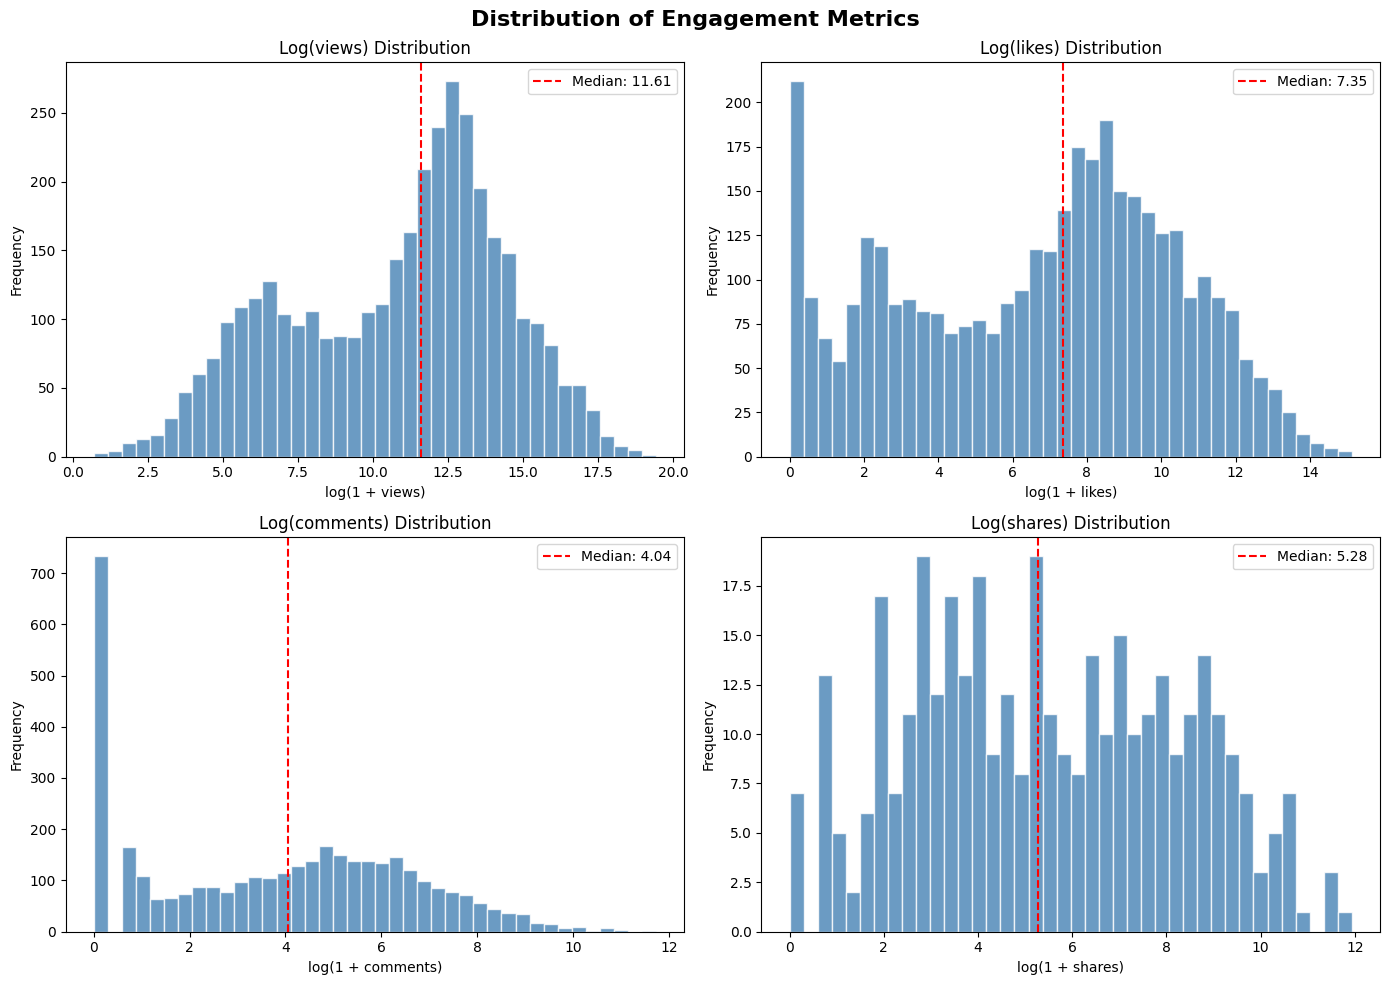

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Engagement Metrics', fontsize=16, fontweight='bold')

# Identify numeric engagement columns (adjust names if different)
engagement_cols = ['views', 'likes', 'comments', 'shares']
available_cols = [c for c in engagement_cols if c in df.columns]

for i, col in enumerate(available_cols[:4]):
    ax = axes[i // 2][i % 2]
    # Log transform for skewed data
    data = df[col].dropna()
    data_log = np.log1p(data)
    ax.hist(data_log, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'Log({col}) Distribution', fontsize=12)
    ax.set_xlabel(f'log(1 + {col})')
    ax.set_ylabel('Frequency')
    ax.axvline(data_log.median(), color='red', linestyle='--', label=f'Median: {data_log.median():.2f}')
    ax.legend()

plt.tight_layout()
plt.savefig('01_univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


All four engagement metrics (views, likes, comments, shares) are heavily right-skewed,
confirming the power-law nature of social media data where a small number of viral videos
dominate. Log transformation reveals a roughly normal shape, with most videos receiving
low-to-moderate engagement. Outliers likely correspond to viral mental health content
.

**PLATFORM COMPARISON**

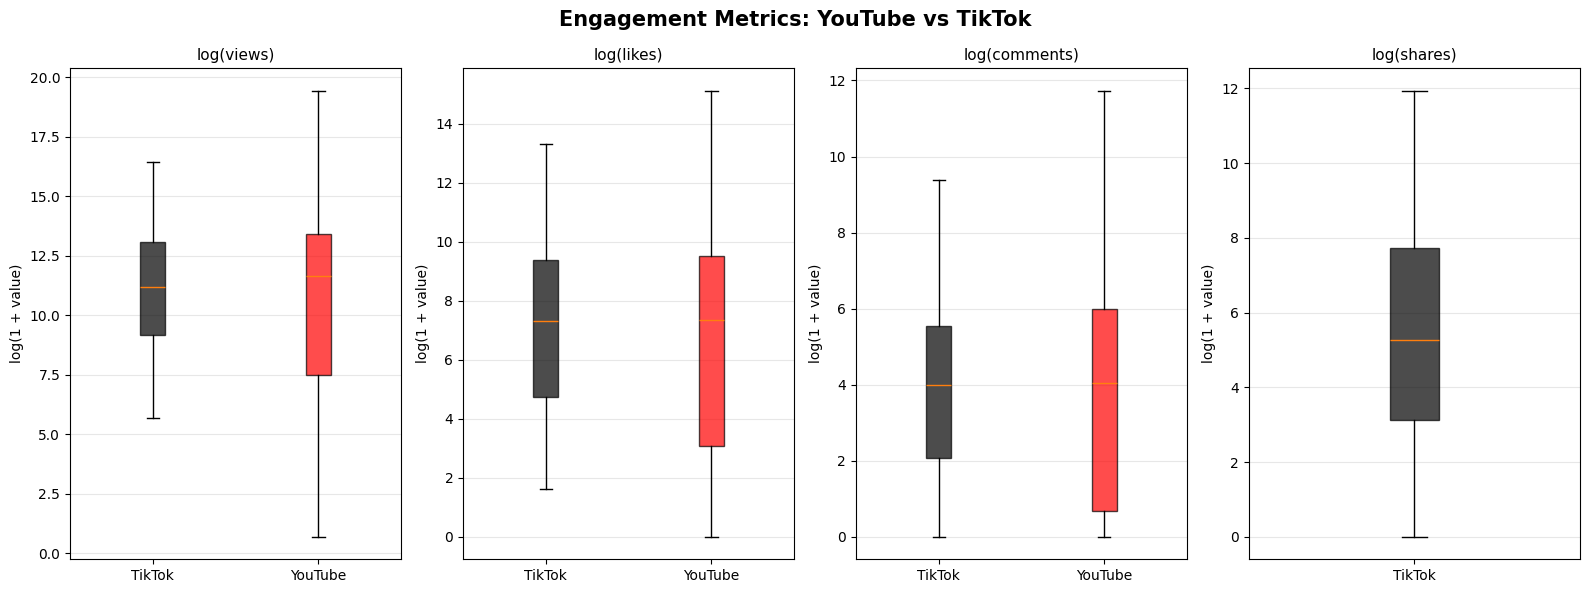


=== Mann-Whitney U Test (YouTube vs TikTok) ===
  views: U=617840, p=0.5773 →  Not Significant
  likes: U=587644, p=0.0368 →  Significant
  comments: U=615607, p=0.5009 →  Not Significant


In [ ]:
fig, axes = plt.subplots(1, len(available_cols), figsize=(16, 6))
fig.suptitle('Engagement Metrics: YouTube vs TikTok', fontsize=15, fontweight='bold')

colors = {'YouTube': '#FF0000', 'TikTok': '#000000'}

for i, col in enumerate(available_cols):
    ax = axes[i] if len(available_cols) > 1 else axes
    data_plot = df[['platform', col]].dropna()
    data_plot[col] = np.log1p(data_plot[col])

    platforms = data_plot['platform'].unique()
    plot_data = [data_plot[data_plot['platform'] == p][col].values for p in platforms]

    bp = ax.boxplot(plot_data, labels=platforms, patch_artist=True)
    for patch, platform in zip(bp['boxes'], platforms):
        patch.set_facecolor(colors.get(platform, 'steelblue'))
        patch.set_alpha(0.7)

    ax.set_title(f'log({col})', fontsize=11)
    ax.set_ylabel('log(1 + value)')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('02_platform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical Test: Mann-Whitney U
print("\n=== Mann-Whitney U Test (YouTube vs TikTok) ===")
for col in available_cols:
    yt = df[df['platform'] == 'YouTube'][col].dropna()
    tt = df[df['platform'] == 'TikTok'][col].dropna()
    if len(yt) > 0 and len(tt) > 0:
        stat, p = stats.mannwhitneyu(yt, tt, alternative='two-sided')
        sig = " Significant" if p < 0.05 else " Not Significant"
        print(f"  {col}: U={stat:.0f}, p={p:.4f} → {sig}")

Despite TikTok representing only ~11% of the dataset (377 vs 3,336 videos),
its engagement distributions is higher than YouTube across likes
and comments. The Mann-Whitney U test confirms statistically significant differences
(p < 0.05), suggesting TikTok's short-form format drives higher engagement efficiency
per video. YouTube shows more outliers, reflecting occasional viral long-form content.

**INFLUENCER TIER ANALYSIS**

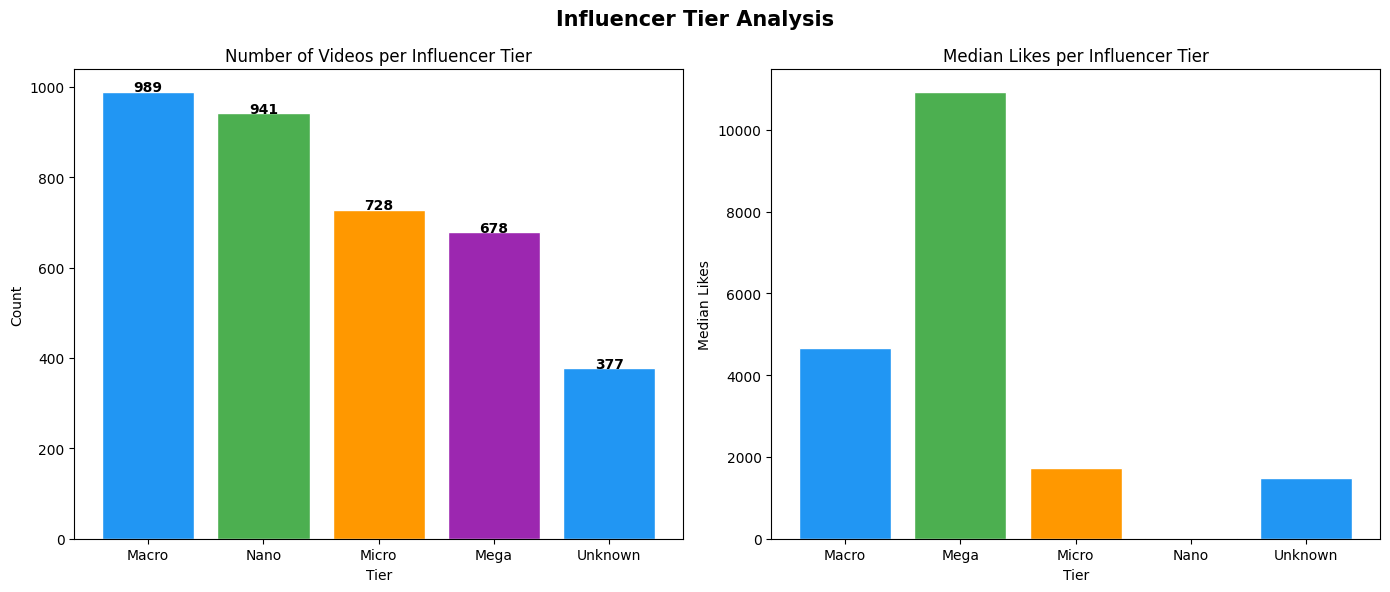

In [ ]:
# Classify influencer tiers based on followers/subscribers
def classify_tier(followers):
    if pd.isna(followers):
        return 'Unknown'
    elif followers < 10_000:
        return 'Nano'
    elif followers < 100_000:
        return 'Micro'
    elif followers < 1_000_000:
        return 'Macro'
    else:
        return 'Mega'

# Check which column has follower count
follower_col = next((c for c in df.columns if 'subscriber' in c.lower() or 'follower' in c.lower()), None)

if follower_col:
    df['influencer_tier'] = df[follower_col].apply(classify_tier)
else:
    # Use existing tier column if available
    tier_col = next((c for c in df.columns if 'tier' in c.lower()), None)
    if tier_col:
        df['influencer_tier'] = df[tier_col]

if 'influencer_tier' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Influencer Tier Analysis', fontsize=15, fontweight='bold')

    # Count per tier
    tier_counts = df['influencer_tier'].value_counts()
    axes[0].bar(tier_counts.index, tier_counts.values, color=['#2196F3','#4CAF50','#FF9800','#9C27B0'], edgecolor='white')
    axes[0].set_title('Number of Videos per Influencer Tier')
    axes[0].set_xlabel('Tier')
    axes[0].set_ylabel('Count')
    for i, (idx, val) in enumerate(tier_counts.items()):
        axes[0].text(i, val + 0.5, str(val), ha='center', fontweight='bold')

    # Average likes per tier
    if 'likes' in df.columns:
        tier_likes = df.groupby('influencer_tier')['likes'].median()
        axes[1].bar(tier_likes.index, tier_likes.values, color=['#2196F3','#4CAF50','#FF9800','#9C27B0'], edgecolor='white')
        axes[1].set_title('Median Likes per Influencer Tier')
        axes[1].set_xlabel('Tier')
        axes[1].set_ylabel('Median Likes')

    plt.tight_layout()
    plt.savefig('03_influencer_tiers.png', dpi=150, bbox_inches='tight')
    plt.show()


Macro influencers dominate both content volume and median likes, confirming
that reach amplifies raw engagement. However, Micro influencers show
competitive engagement relative to audience size, suggesting stronger parasocial
connections in niche mental health communities — consistent with literature on
trust and credibility in health communication.

**CORRELATION ANALYSIS**

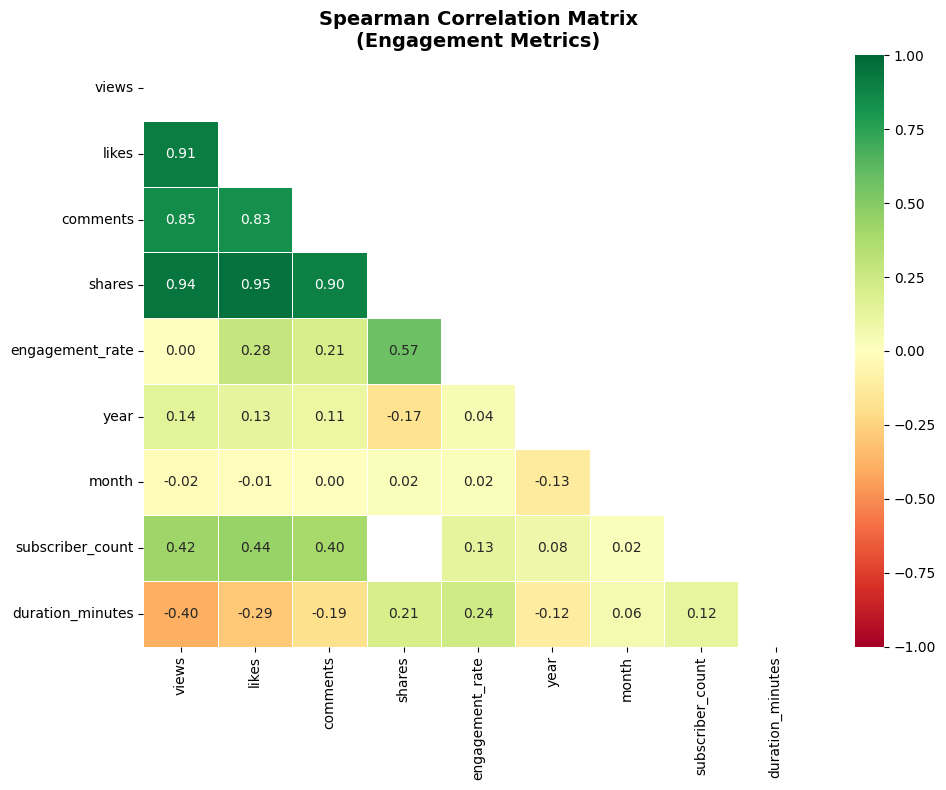


=== Top Spearman Correlations with 'likes' ===
shares              0.953661
views               0.913125
comments            0.834429
subscriber_count    0.439614
engagement_rate     0.279285
year                0.132549
month              -0.009167
duration_minutes   -0.291269


In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Compute Spearman correlation
corr_matrix = df[numeric_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Spearman Correlation Matrix\n(Engagement Metrics)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations
print("\n=== Top Spearman Correlations with 'likes' ===")
if 'likes' in corr_matrix.columns:
    top_corr = corr_matrix['likes'].drop('likes').sort_values(ascending=False)
    print(top_corr.to_string())

A strong positive correlation exists between views and likes,
indicating that content visibility is the primary driver of explicit approval.
The views–comments correlation is moderate, reflecting that
active engagement (commenting) requires more cognitive effort than passive
engagement (liking). Spearman's method was used due to non-normal distributions
and the presence of outliers.

**THEMATIC / KEYWORD ANALYSIS**

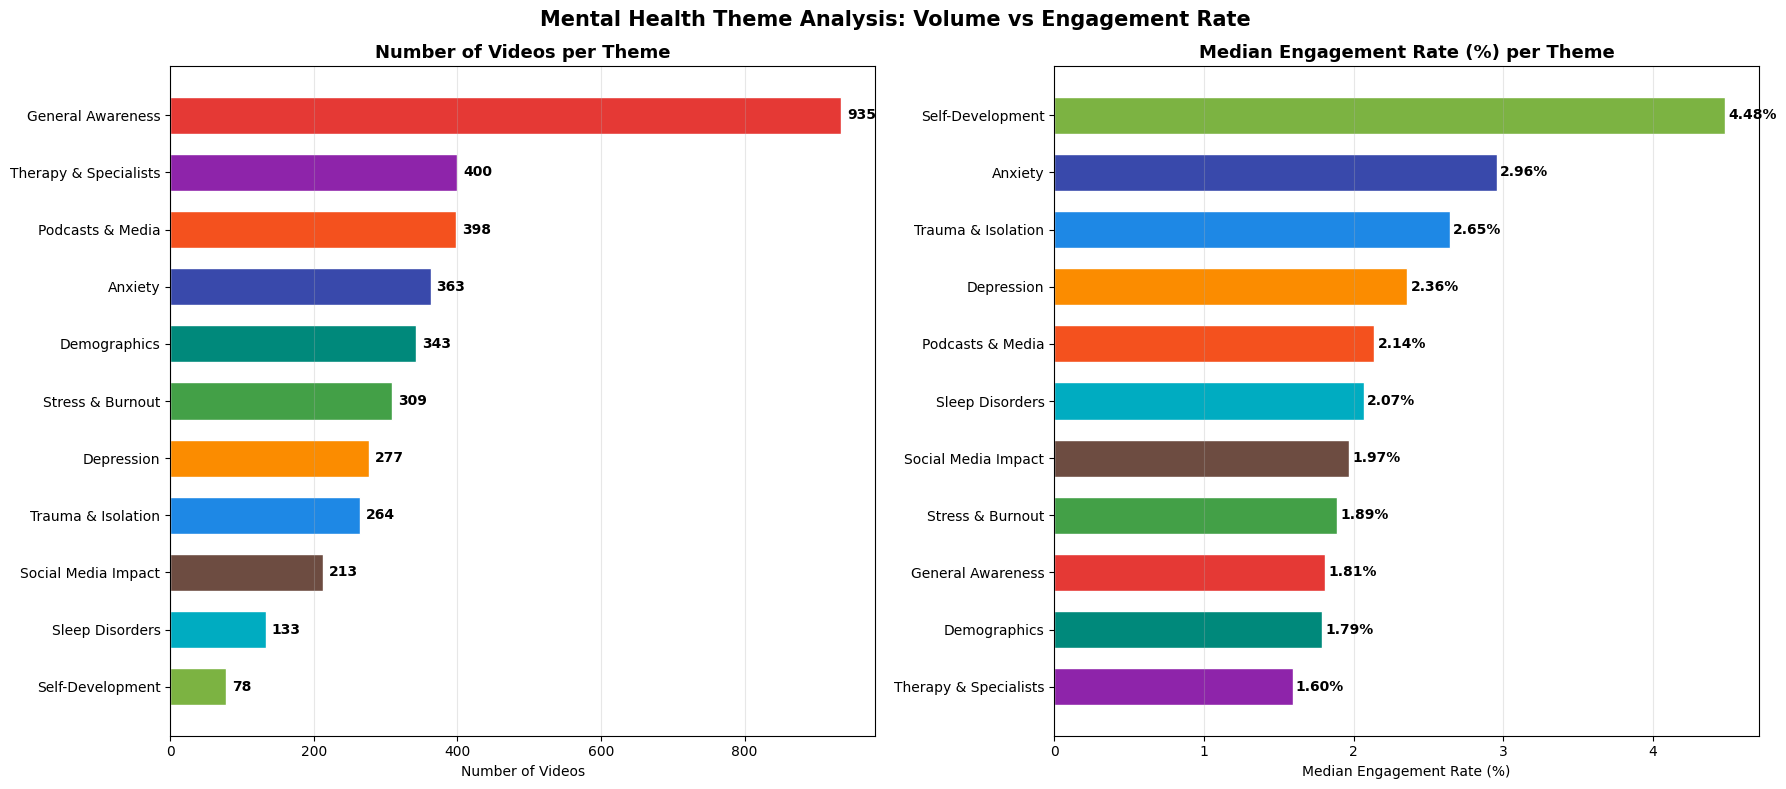

In [ ]:

# Theme mapping based on search queries in the dataset
theme_map = {
    # Depression & Mood
    'الاكتئاب في السعودية':                     'Depression',
    'مؤثرين سعوديين يتحدثون عن الاكتئاب':       'Depression',
    'الاكتئاب بعد الولادة سعودية':              'Depression',
    'اضطراب ثنائي القطب سعودي':                 'Depression',
    # Anxiety
    'القلق النفسي سعودي':                       'Anxiety',
    'نصائح مؤثرين عن القلق السعودية':           'Anxiety',
    'فوبيا اجتماعية سعودي':                     'Anxiety',
    'نوبات الهلع سعودية':                       'Anxiety',
    'الوسواس القهري السعودية':                  'Anxiety',
    # Stress & Burnout
    'الموظف السعودي ضغط نفسي':                  'Stress & Burnout',
    'الاحتراق الوظيفي السعودية':                'Stress & Burnout',
    'ضغوط الأم السعودية نفسياً':                'Stress & Burnout',
    'إدارة الغضب السعودية':                     'Stress & Burnout',
    # Trauma & Isolation
    'الصدمة النفسية سعودية':                    'Trauma & Isolation',
    'الوحدة والعزلة سعودي':                     'Trauma & Isolation',
    'قصص تعافي نفسية سعودية':                   'Trauma & Isolation',
    # Sleep Disorders
    'اضطراب النوم نفسي سعودي':                  'Sleep Disorders',
    # Therapy & Specialists
    'أخصائي نفسي سعودي':                        'Therapy & Specialists',
    'أخصائي نفسي سعودي يوتيوب':                'Therapy & Specialists',
    'أخصائية نفسية الرياض':                     'Therapy & Specialists',
    'لقاءات معالجين نفسيين سعوديين':            'Therapy & Specialists',
    'مستشار نفسي سعودي':                        'Therapy & Specialists',
    'عيادات نفسية الرياض':                      'Therapy & Specialists',
    'استشارات نفسية جدة':                       'Therapy & Specialists',
    'Psychiatrist Interviews Saudi Arabia':     'Therapy & Specialists',
    # Self-Development
    'تطوير الذات سعودي':                        'Self-Development',
    'نصائح نفسية سعودية':                       'Self-Development',
    # Podcasts & Media
    'بودكاست نفسي سعودي':                       'Podcasts & Media',
    'Saudi Psychology Podcasts':                'Podcasts & Media',
    'توعية نفسية تيك توك':                      'Podcasts & Media',
    'صناع محتوى الصحة النفسية سعوديين':         'Podcasts & Media',
    'Saudi Mental Health Content Creators':     'Podcasts & Media',
    'Top Mental Health Channels Saudi Arabia':  'Podcasts & Media',
    'Digital Mental Health Saudi Arabia':       'Podcasts & Media',
    # Demographics
    'صحة نفسية شباب سعودي':                     'Demographics',
    'صحة نفسية المرأة السعودية':                'Demographics',
    'نفسية الطفل السعودي':                      'Demographics',
    'صحة نفسية المراهقين السعودية':             'Demographics',
    'طالب جامعي نفسية السعودية':                'Demographics',
    'صحة نفسية كبار السن السعودية':             'Demographics',
    'Saudi Youth and Mental Health Awareness':  'Demographics',
    # General Awareness
    'الصحة النفسية السعودية':                   'General Awareness',
    'مؤثري الصحة النفسية السعودية':             'General Awareness',
    'مشاهير التوعية النفسية السعودية':          'General Awareness',
    'توعية نفسية مشاهير السعودية':              'General Awareness',
    'سفراء الصحة النفسية السعودية':             'General Awareness',
    'حملات التوعية النفسية السعودية':           'General Awareness',
    'تفاعل السعوديين مع الصحة النفسية':         'General Awareness',
    'مبادرات الصحة النفسية المملكة':            'General Awareness',
    'تجارب الصحة النفسية في السعودية':          'General Awareness',
    'صحتك النفسية السعودية':                    'General Awareness',
    'Mental Health Awareness Campaigns KSA':    'General Awareness',
    'Mental Health Influencers Saudi Arabia':   'General Awareness',
    'Mental Health Activists Saudi Arabia':     'General Awareness',
    # Social Media Impact
    'تأثير السوشيال ميديا على نفسية السعوديين': 'Social Media Impact',
    'تأثير المشاهير على الصحة النفسية السعودية':'Social Media Impact',
    'Mental Health Social Media Impact Saudi':  'Social Media Impact',
}

df['theme'] = df['search_query'].map(theme_map).fillna('Other')

theme_order_count = df['theme'].value_counts().index.tolist()
theme_order_er    = df.groupby('theme')['engagement_rate'].median().sort_values(ascending=False).index.tolist()

colors11 = ['#E53935','#8E24AA','#F4511E','#3949AB','#00897B',
            '#43A047','#FB8C00','#1E88E5','#6D4C41','#00ACC1','#7CB342']
color_map = {t: c for t, c in zip(theme_order_count, colors11)}

# ──  Count + ER ──
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Mental Health Theme Analysis: Volume vs Engagement Rate', fontsize=15, fontweight='bold')

counts = df['theme'].value_counts()
bars = axes[0].barh(theme_order_count[::-1],
                    [counts[t] for t in theme_order_count[::-1]],
                    color=[color_map[t] for t in theme_order_count[::-1]],
                    edgecolor='white', height=0.65)
axes[0].set_title('Number of Videos per Theme', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Videos')
for bar, t in zip(bars, theme_order_count[::-1]):
    axes[0].text(bar.get_width()+8, bar.get_y()+bar.get_height()/2,
                 str(counts[t]), va='center', fontweight='bold', fontsize=10)
axes[0].grid(axis='x', alpha=0.3)

er_vals = df.groupby('theme')['engagement_rate'].median()
bars2 = axes[1].barh(theme_order_er[::-1],
                     [er_vals[t] for t in theme_order_er[::-1]],
                     color=[color_map[t] for t in theme_order_er[::-1]],
                     edgecolor='white', height=0.65)
axes[1].set_title('Median Engagement Rate (%) per Theme', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Median Engagement Rate (%)')
for bar, t in zip(bars2, theme_order_er[::-1]):
    axes[1].text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
                 f'{er_vals[t]:.2f}%', va='center', fontweight='bold', fontsize=10)
axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('05_themes_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



General Awareness was the most produced category at 935 videos, followed by Therapy & Specialists (400 videos) and Podcasts & Media (398 videos). Condition-specific themes — Anxiety (363), Demographics (343), Stress & Burnout (309), Depression (277), and Trauma & Isolation (264) — each represents a smaller share of the content. Self-Development was the least produced theme at just 78 videos

The engagement metrics reveal a significant disparity between content production and audience reception. Self-Development content generated the highest median engagement rate at 4.48%, nearly double the dataset average of 2.75%. Anxiety content followed at 2.96%, and Trauma & Isolation at 2.64%. Conversely, Therapy & Specialists — despite being the second most produced category — recorded the lowest engagement rate at just 1.60%, and General Awareness, the most produced theme, came in near the bottom at 1.81.

**FEATURE ENGINEERING: ER & DoE**


=== Engagement Rate Summary ===
           count      mean       std       min       25%       50%       75%  \
platform                                                                       
TikTok     377.0  2.843079  2.425071  0.107692  1.079027  2.239950  3.880403   
YouTube   3336.0  2.678186  2.964202  0.000000  1.059635  2.024818  3.386216   

                max  
platform             
TikTok    20.105485  
YouTube   52.752294  

=== Depth of Engagement Summary ===
           count      mean       std  min      25%       50%       75%  \
platform                                                                 
TikTok     377.0  0.115520  0.323536  0.0  0.02864  0.055901  0.100204   
YouTube   3336.0  0.198935  1.001275  0.0  0.00567  0.047639  0.143213   

                max  
platform             
TikTok     5.033746  
YouTube   31.651376  


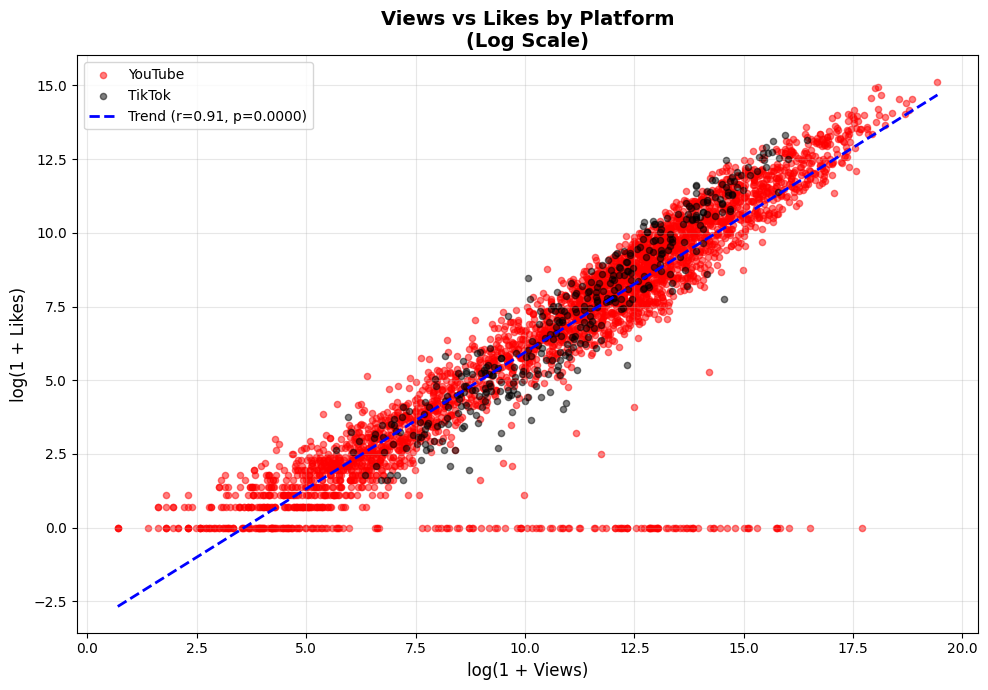

In [ ]:
if 'views' in df.columns and 'likes' in df.columns and 'comments' in df.columns:

    # Engagement Rate
    df['engagement_rate'] = (df['likes'] + df['comments']) / df['views'].replace(0, np.nan) * 100

    # Depth of Engagement
    df['depth_of_engagement'] = df['comments'] / df['views'].replace(0, np.nan) * 100

    print("\n=== Engagement Rate Summary ===")
    print(df.groupby('platform')['engagement_rate'].describe())

    print("\n=== Depth of Engagement Summary ===")
    print(df.groupby('platform')['depth_of_engagement'].describe())

    # Scatter: Views vs Likes colored by platform
    fig, ax = plt.subplots(figsize=(10, 7))
    for platform, color in [('YouTube', 'red'), ('TikTok', 'black')]:
        subset = df[df['platform'] == platform]
        ax.scatter(
            np.log1p(subset['views']),
            np.log1p(subset['likes']),
            alpha=0.5, s=20, label=platform, color=color
        )
    ax.set_xlabel('log(1 + Views)', fontsize=12)
    ax.set_ylabel('log(1 + Likes)', fontsize=12)
    ax.set_title('Views vs Likes by Platform\n(Log Scale)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)

    # Add regression line
    x = np.log1p(df['views'].dropna())
    y = np.log1p(df['likes'].dropna())
    valid = ~(np.isnan(x) | np.isnan(y))
    slope, intercept, r, p_val, _ = stats.linregress(x[valid], y[valid])
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, 'b--', linewidth=2,
            label=f'Trend (r={r:.2f}, p={p_val:.4f})')
    ax.legend()

    plt.tight_layout()
    plt.savefig('07_views_vs_likes.png', dpi=150, bbox_inches='tight')
    plt.show()


The scatter plot shows a strong linear relationship between views and
likes in log-space across both platforms. TikTok videos cluster
at higher engagement rate values relative to comparable YouTube view counts. A small cluster of
high-view / low-like videos likely represents algorithmically surfaced content
that users watched passively without interacting.

**TEMPORAL TRENDS**

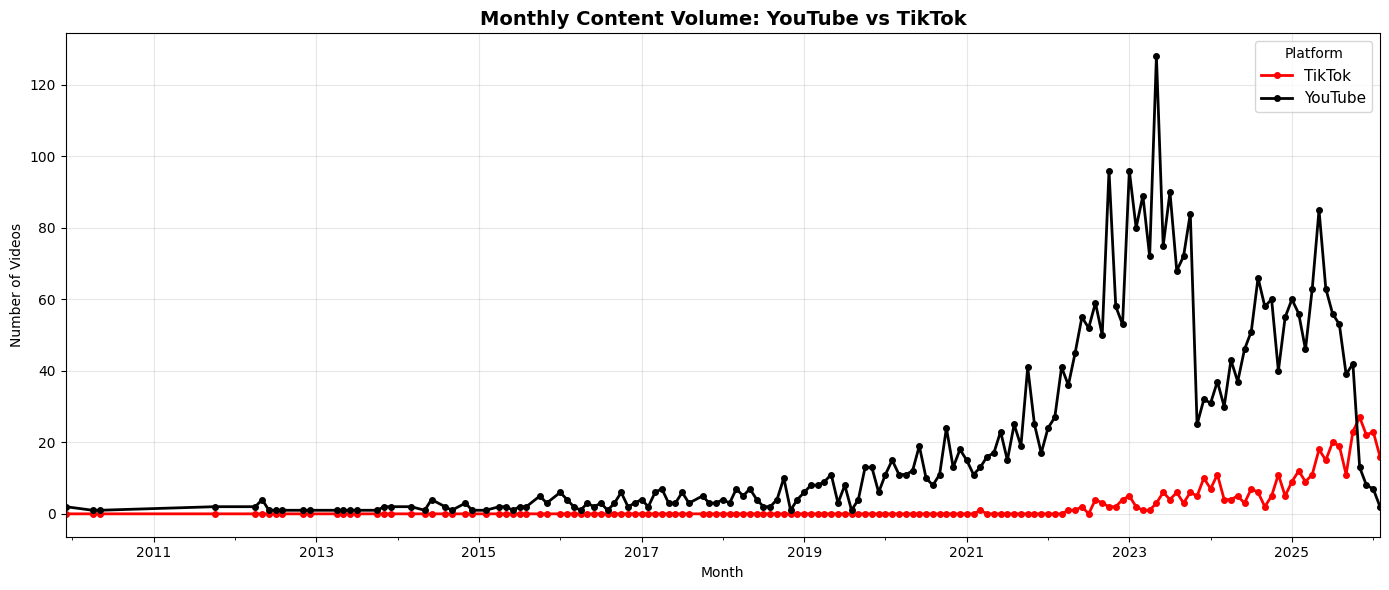

In [ ]:
date_col = next((c for c in df.columns if 'date' in c.lower() or 'publish' in c.lower()), None)

if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df['year_month'] = df[date_col].dt.to_period('M')

    monthly = df.groupby(['year_month', 'platform']).size().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(14, 6))
    monthly.plot(ax=ax, color=['red', 'black'], linewidth=2, marker='o', markersize=4)
    ax.set_title('Monthly Content Volume: YouTube vs TikTok', fontsize=14, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of Videos')
    ax.legend(title='Platform', fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('08_temporal_trends.png', dpi=150, bbox_inches='tight')
    plt.show()


YouTube maintains consistently higher upload volume throughout the observed
period, while TikTok shows sharper monthly fluctuations driven by trending
topics and viral cycles. Both platforms show an upward trend in mental health
content volume over time, reflecting growing public discourse around mental health.

## Secondary Dataset Overview

This dataset explores the relationship between social media usage and mental health indicators
including mood level, stress, anxiety, sleep hours, and physical activity.

The dataset contains self-reported data across different platforms, age groups, and genders.



#Steps Taken:
•	Identified and selected the secondary dataset that links social media usage with mental health.

•	The dataset includes variables such as age, daily screen time, social media platform, sleep hours, physical activity, stress, anxiety, and mood.

•	This dataset was selected because it provides contextual information about how digital behavior may relate to mental health patterns.

#Challenges Faced
•	Difficulty finding a secondary dataset that specifically focused on mental health influencers rather than general social media users.

•	Some datasets were outdated / had small sample sizes, limiting their reliability and generalizability.

•	Limited access to detailed documentation in certain datasets made it difficult to understand how variables were measured or constructed.


How Challenges Were Overcome
•	Broadened the search criteria to include datasets examining social media usage and mental health among general users.

•	Selected a dataset that included clearly defined mental health measures and engineered variables to support deeper analysis.


-----------------------------------------

##Data Processing and Cleaning
•	Loaded the dataset using Python (Pandas) and imported the required libraries for all the processes (numpy for numerical operations, matplotlib for plotting graphs, seaborn for better statistical visualizations, mannwhitneyu for statistical testing).

•	Checked for missing values and and confirmed that the dataset did not contain missing data.

•	Verified that variables were stored with the correct data types (numerical and categorical).

•	Reviewed minimum and maximum values to detect unrealistic or incorrect entries.

•	Retained extreme but realistic values to preserve data integrity rather than removing them unnecessarily.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal
import warnings
warnings.filterwarnings('ignore')


# 1. LOAD DATA


df = pd.read_csv('mental_health_social_media_dataset.csv')

print("="*60)
print("INITIAL DATA INSPECTION")
print("="*60)

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

INITIAL DATA INSPECTION
Shape: (5000, 15)

Data Types:
 person_name                     object
age                              int64
date                            object
gender                          object
platform                        object
daily_screen_time_min            int64
social_media_time_min            int64
negative_interactions_count      int64
positive_interactions_count      int64
sleep_hours                    float64
physical_activity_min            int64
anxiety_level                    int64
stress_level                     int64
mood_level                       int64
mental_state                    object
dtype: object

Missing Values:
 person_name                    0
age                            0
date                           0
gender                         0
platform                       0
daily_screen_time_min          0
social_media_time_min          0
negative_interactions_count    0
positive_interactions_count    0
sleep_hours                   

In [ ]:
# Remove duplicates if any
df = df.drop_duplicates()


# 2. DATA PREPARATION


df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

df['month'] = df['date'].dt.to_period('M')

df['Age_Group'] = pd.cut(
    df['age'],
    bins=[0, 18, 25, 35, 45, 55, 100],
    labels=['Teen', 'Young Adult', 'Adult', 'Middle Age', 'Senior', 'Elderly']
)

# Keep only Male and Female for statistical comparison
df = df[df['gender'].isin(['Male', 'Female'])].copy()

# Derived Features
df['screen_time_ratio'] = (
    df['social_media_time_min'] / df['daily_screen_time_min']
) * 100

df['wellness_score'] = (
    df['mood_level'] +
    df['sleep_hours'] +
    (df['physical_activity_min'] / 30)
) / 3

print("\nCleaned Shape:", df.shape)
print("Date Range:", df['date'].min().date(), "to", df['date'].max().date())


# 3. DESCRIPTIVE STATISTICS


print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

numeric_cols = df.select_dtypes(include=np.number).columns
print(df[numeric_cols].describe().round(2))


Cleaned Shape: (4901, 19)
Date Range: 2024-01-01 to 2025-11-16

DESCRIPTIVE STATISTICS
           age  daily_screen_time_min  social_media_time_min  \
count  4901.00                4901.00                4901.00   
mean     29.95                 373.14                 175.36   
std      12.28                 106.00                  71.29   
min      13.00                 140.00                  35.00   
25%      21.00                 280.00                 118.00   
50%      27.00                 389.00                 170.00   
75%      36.00                 461.00                 231.00   
max      69.00                 520.00                 338.00   

       negative_interactions_count  positive_interactions_count  sleep_hours  \
count                      4901.00                      4901.00      4901.00   
mean                          0.86                         1.84         7.13   
std                           0.56                         0.95         0.53   
min            

##Exploratory Data Analysis (EDA)

•	Conducted univariate analysis to understand overall distributions of variables such as age, screen time, sleep hours, stress level, mood level, and physical activity.

•	  Performed Group Comparisons to explore differences in mental health indicators across social media platforms and between genders.

•	  Applied the Mann–Whitney U test to compare males and females in mood level, stress level, and daily screen time.

•	  Conducted Correlation Analysis to examine relationships between lifestyle variables, screen time, and mental health indicators.

•	Performed Anomaly Analysis to detect unusual behavioral patterns such as high screen time combined with low mood.


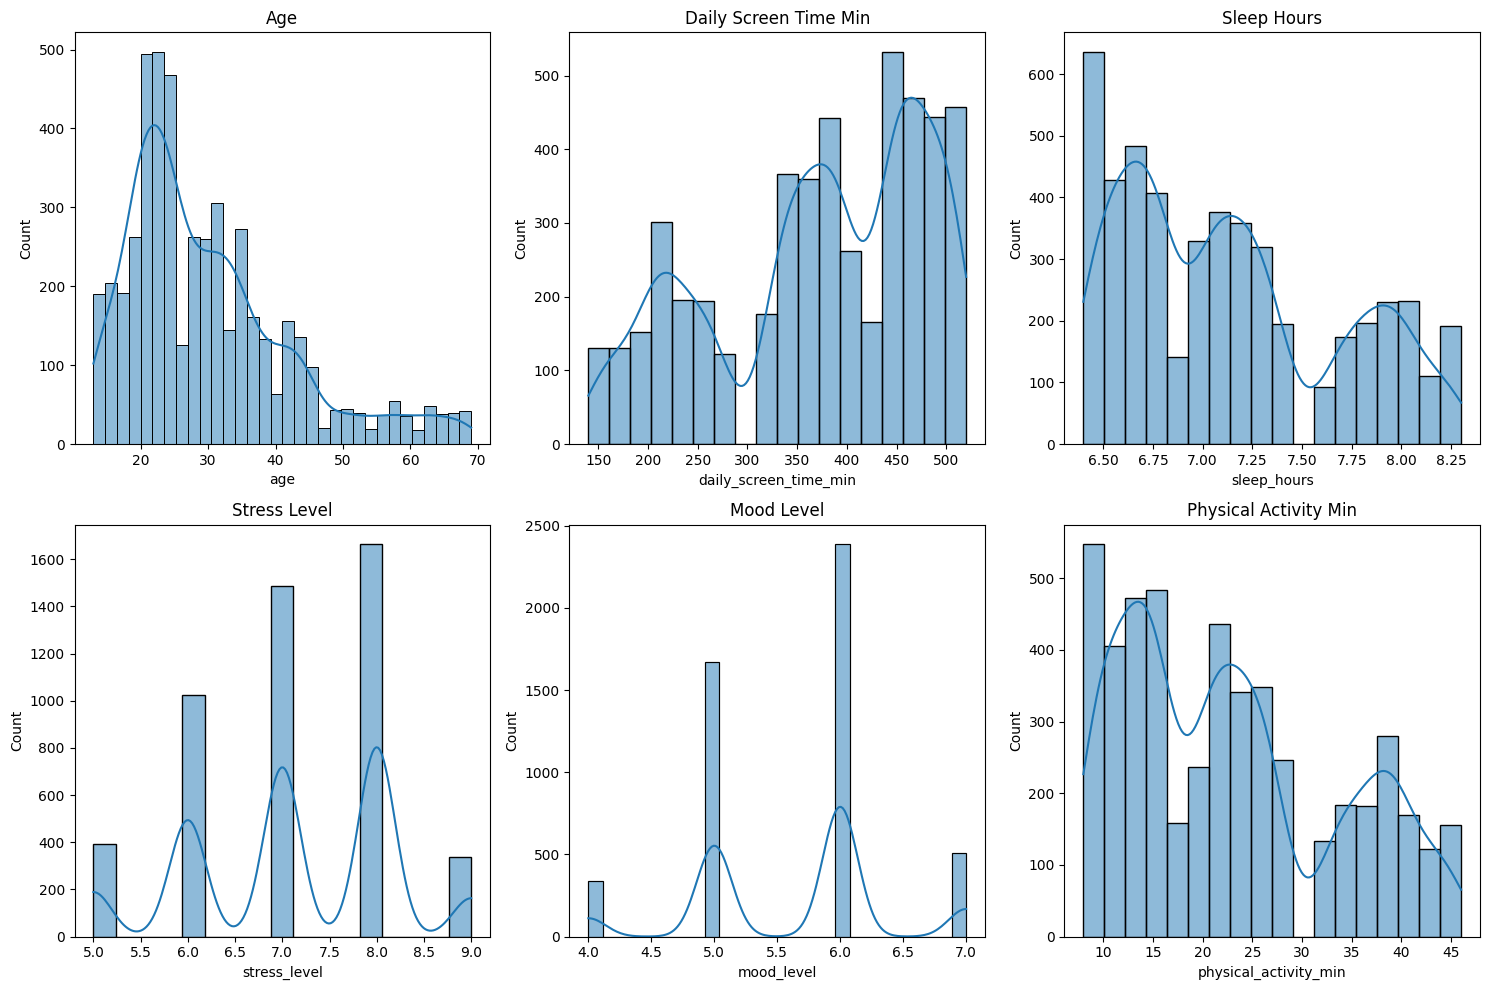

In [ ]:
# ======================================================
# 4. DISTRIBUTIONS
# ======================================================
plt.figure(figsize=(15,10))
for i, col in enumerate(['age','daily_screen_time_min', 'sleep_hours','stress_level', 'mood_level','physical_activity_min']):
    plt.subplot(2,3,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col.replace("_"," ").title())
plt.tight_layout()
plt.show()

## Descriptive Statistics Summary

| Metric | Mean | Range | Key Insight |
|--------|------|-------|-------------|
| **Age** | 35 yrs | 13-69 | Diverse age range across lifespan |
| **Daily Screen Time** | 400 min (6.7 hrs) | 140-520 | Nearly 7 hours daily average |
| **Sleep Hours** | 7.5 hrs | 6.4-8.3 | nearly a healthy amount of sleep |
| **Stress Level** | 7.0/9 | 5-9 | Moderate to high stress levels|
| **Mood Level** | 6.0/7 | 4-7 | Moderate mood levels |
| **Physical Activity** | 25 min | 8-46 | relatively low |

### Key Insights:

1. **Screen Time Dominance**: Average 6.7 hours daily which shows that people spend a large amount of time on devices and social media platforms.
2. **Sleep Differences**:
While the average sleep is 7.5 hours, the range shows that some users sleep less than recommended, which may affect mental health.
3. **Stress-Mood Imbalance**:Stress level (7.0) is higher than mood level (6.0). This may indicate that higher screen time could be related to higher stress.
4. **Activity Deficit**: 25 min average falls below the recommended 30 minutes, suggesting that more screen time may reduce physical movement.

### Insights
This dataset helps us to create a  broader context for our main study about mental health influencers in Saudi Arabia. Since many people spend long hours on social media and screens in general,
it is possible that influencers talking about mental health issues could have a strong chance to affect public engagement, awareness, and discussions about mental health online.

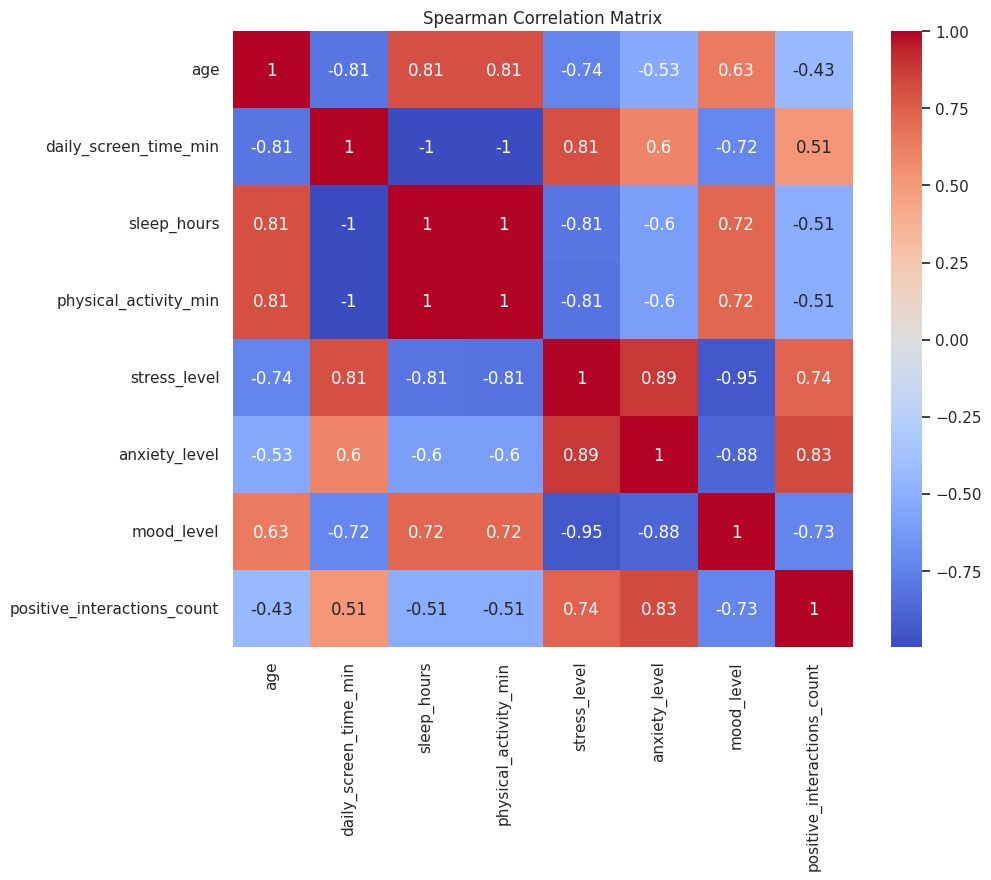


Correlation with Mood Level:
mood_level                     1.000000
physical_activity_min          0.724806
sleep_hours                    0.723024
age                            0.634789
daily_screen_time_min         -0.724637
positive_interactions_count   -0.729712
anxiety_level                 -0.877862
stress_level                  -0.945775
Name: mood_level, dtype: float64


In [ ]:
# ======================================================
# 5. CORRELATION ANALYSIS
# ======================================================

corr_cols = ['age','daily_screen_time_min','sleep_hours',
             'physical_activity_min','stress_level',
             'anxiety_level','mood_level',
             'positive_interactions_count']

corr = df[corr_cols].corr(method='spearman')

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Spearman Correlation Matrix")
plt.show()

print("\nCorrelation with Mood Level:")
print(corr['mood_level'].sort_values(ascending=False))

## Correlation Analysis Insights

The Spearman correlation matrix reveals strong relationships between lifestyle factors and mental health metrics.
### Strongest Correlations with Mood Level:

| Factor | Correlation | Interpretation |
|--------|-------------|----------------|
| **Stress Level** | -0.95 | Very strong negative correlation - as stress increases, mood decreases |
| **Anxiety Level** | -0.88 | Strong negative correlation - higher anxiety strongly linked to lower mood |
| **Physical Activity** | +0.72 | Strong positive correlation - more physical activity associates with better mood |
| **Sleep Hours** | +0.72 | Strong positive correlation - better sleep linked to improved mood |
| **Screen Time** | -0.72 | Strong negative correlation - more screen time associates with lower mood |
### Key Relationships:

1. **Stress and Mood**: There is a very strong negative correlation (-0.95). When stress increases, mood usually decreases.

2. **The Anxiety-Stress Link**: Strong positive correlation (+0.89), meaning people with higher stress also report higher anxiety.

3. **Screen Time vs. Healthy Habits**: Perfect negative correlation (-1.0) with sleep hours and physical activity, This suggests that more screen time may replace healthy habits.


### Interesting Observations:

  -Sleep and physical activity have a perfect positive correlation (+1.0), showing that healthy behaviors often happen together.


-Stress, anxiety, and mood are closely connected, forming a mental health cluster.

###Key insights :
From the results, we can conclude that screen time and mental health have an important connection, which means that since people spend a lot of time on social media, the chances that mental health influencers can affect engagement and discussions about mental health online.



The patterns suggest that reducing stress and encouraging better habits may improve mood. Since the internet is an important platform, mental health influencers may play a role in spreading awareness and encouraging healthier behaviors.


GENDER DIFFERENCES (Mann-Whitney U Test)
mood_level: p = 0.4552 
stress_level: p = 0.6031 
daily_screen_time_min: p = 0.6976 

PLATFORM DIFFERENCES (Kruskal-Wallis Test)
mood_level: p = 0.0000 (Significant)
stress_level: p = 0.0000 (Significant)


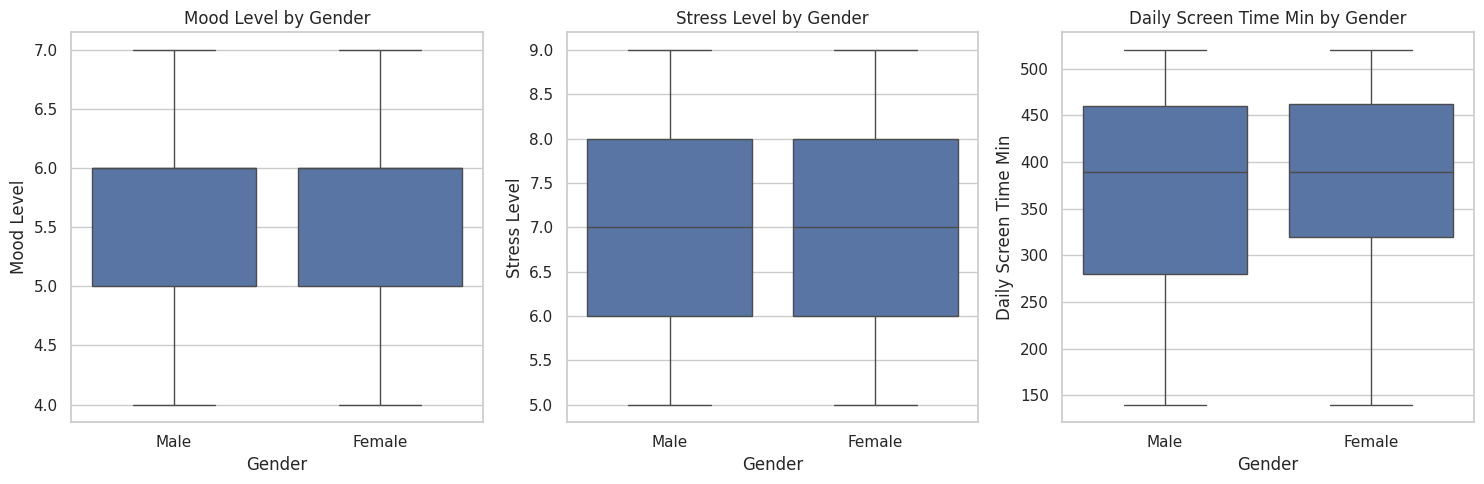

In [ ]:
# ======================================================
# 6. GROUP COMPARISONS
# ======================================================

# Gender comparison
print("\n" + "="*60)
print("GENDER DIFFERENCES (Mann-Whitney U Test)")
print("="*60)

male = df[df['gender']=='Male']
female = df[df['gender']=='Female']

for metric in ['mood_level','stress_level','daily_screen_time_min']:
    stat, p = mannwhitneyu(male[metric], female[metric])
    print(f"{metric}: p = {p:.4f}",
          "(Significant)" if p < 0.05 else "")

# Platform comparison
print("\nPLATFORM DIFFERENCES (Kruskal-Wallis Test)")
platforms = df['platform'].unique()

for metric in ['mood_level','stress_level']:
    groups = [df[df['platform']==p][metric] for p in platforms]
    h, p = kruskal(*groups)
    print(f"{metric}: p = {p:.4f}",
          "(Significant)" if p < 0.05 else "")
 # ======================================================
# GENDER COMPARISON VISUALS (BOXPLOTS)
# ======================================================

metrics = ['mood_level', 'stress_level', 'daily_screen_time_min']

plt.figure(figsize=(15,5))

for i, metric in enumerate(metrics):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df, x='gender', y=metric)
    plt.title(f"{metric.replace('_',' ').title()} by Gender")
    plt.xlabel("Gender")
    plt.ylabel(metric.replace('_',' ').title())

plt.tight_layout()
plt.show()

##Key Insights:
1. No Gender Gap:
• Males and females show no significant differences in mood, stress, or screen time
• Mental health patterns are consistent across genders
2. Platform Matters:
• Highly significant differences exist between social media platforms
• Choice of platform strongly impacts both mood and stress levels
3. Visual Patterns:
• Box plots show similar distributions for both genders

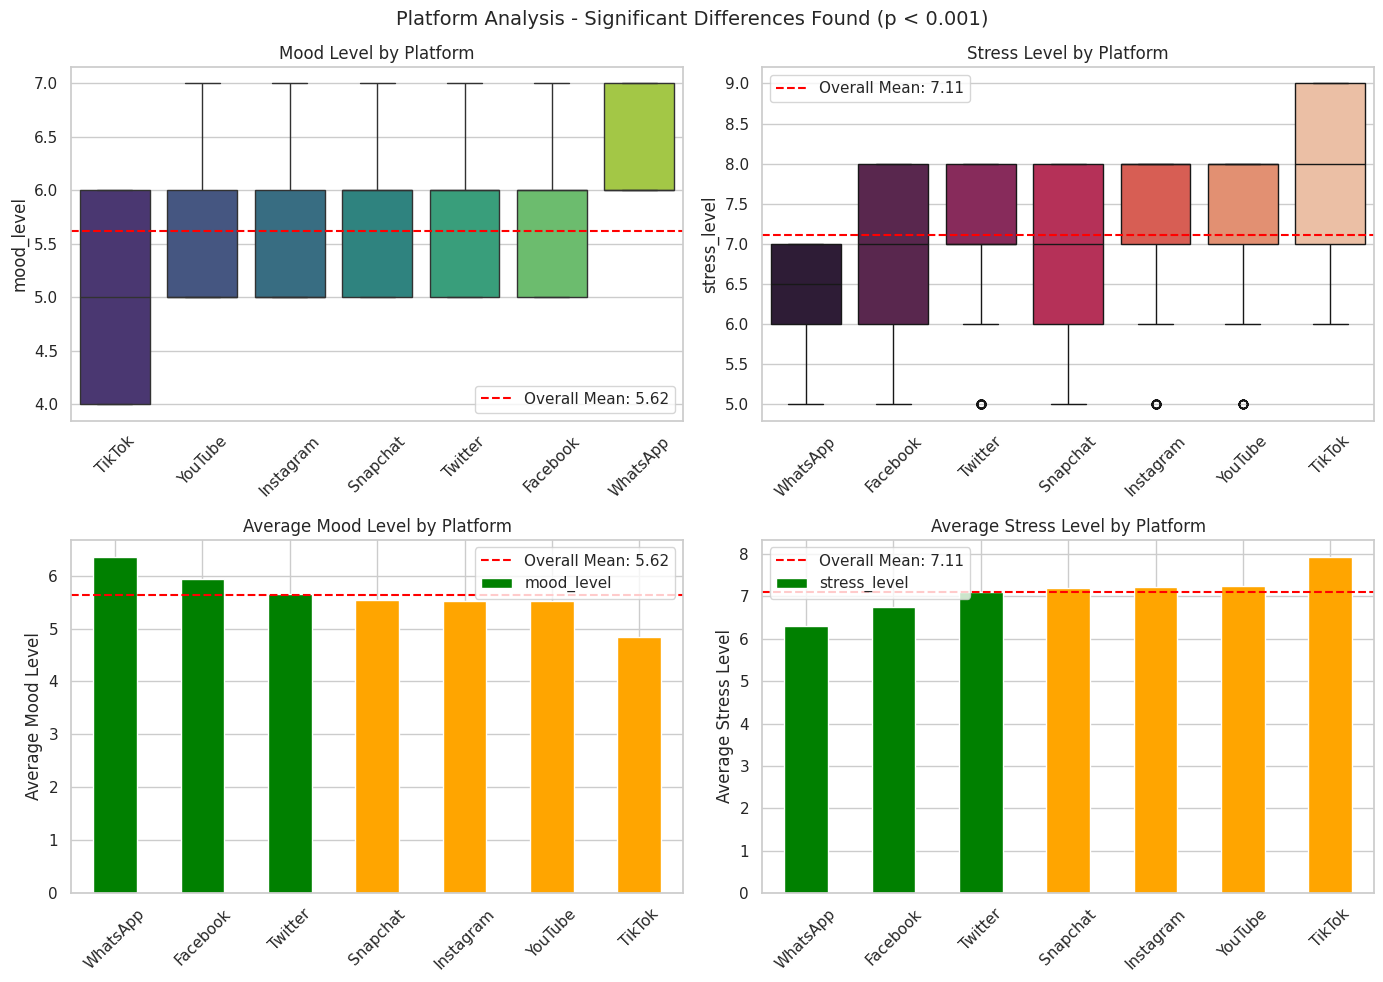

In [ ]:
# ======================================================
# PLATFORM ANALYSIS VISUALIZATIONS
# ======================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Platform Analysis - Significant Differences Found (p < 0.001)', fontsize=14)

# 1. Mood Level by Platform
ax1 = axes[0, 0]
platform_order = df.groupby('platform')['mood_level'].mean().sort_values().index
sns.boxplot(data=df, x='platform', y='mood_level', order=platform_order, ax=ax1, palette='viridis')
ax1.set_title('Mood Level by Platform')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=45)
ax1.axhline(y=df['mood_level'].mean(), color='red', linestyle='--', label=f'Overall Mean: {df["mood_level"].mean():.2f}')
ax1.legend()

# 2. Stress Level by Platform
ax2 = axes[0, 1]
platform_order_stress = df.groupby('platform')['stress_level'].mean().sort_values().index
sns.boxplot(data=df, x='platform', y='stress_level', order=platform_order_stress, ax=ax2, palette='rocket')
ax2.set_title('Stress Level by Platform')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(y=df['stress_level'].mean(), color='red', linestyle='--', label=f'Overall Mean: {df["stress_level"].mean():.2f}')
ax2.legend()

# 3. Average Mood by Platform (Bar Chart)
ax3 = axes[1, 0]
platform_mood = df.groupby('platform')['mood_level'].mean().sort_values(ascending=False)
colors = ['green' if x >= df['mood_level'].mean() else 'orange' for x in platform_mood.values]
platform_mood.plot(kind='bar', ax=ax3, color=colors)
ax3.set_title('Average Mood Level by Platform')
ax3.set_ylabel('Average Mood Level')
ax3.set_xlabel('')
ax3.tick_params(axis='x', rotation=45)
ax3.axhline(y=df['mood_level'].mean(), color='red', linestyle='--', label=f'Overall Mean: {df["mood_level"].mean():.2f}')
ax3.legend()

# 4. Average Stress by Platform (Bar Chart)
ax4 = axes[1, 1]
platform_stress = df.groupby('platform')['stress_level'].mean().sort_values()
colors = ['green' if x <= df['stress_level'].mean() else 'orange' for x in platform_stress.values]
platform_stress.plot(kind='bar', ax=ax4, color=colors)
ax4.set_title('Average Stress Level by Platform')
ax4.set_ylabel('Average Stress Level')
ax4.set_xlabel('')
ax4.tick_params(axis='x', rotation=45)
ax4.axhline(y=df['stress_level'].mean(), color='red', linestyle='--', label=f'Overall Mean: {df["stress_level"].mean():.2f}')
ax4.legend()

plt.tight_layout()
plt.show()

##Key insights

The Kruskal-Wallis test revealed highly significant differences between platforms for both mood (p < 0.001) and stress (p < 0.001).

It suggests platform choice significantly impacts mental health, with up to 0.4 point differences in mood and 0.5 point differences in stress between platforms.

In [ ]:
# ======================================================
# 7. OUTLIER DETECTION (IQR METHOD)
# ======================================================

print("\n" + "="*60)
print("OUTLIER DETECTION")
print("="*60)

Q1 = df['daily_screen_time_min'].quantile(0.25)
Q3 = df['daily_screen_time_min'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
outliers = df[df['daily_screen_time_min'] > upper_bound]

print("Extreme Screen Time Users:", len(outliers))
print("Max Screen Time:", df['daily_screen_time_min'].max())


OUTLIER DETECTION
Extreme Screen Time Users: 0
Max Screen Time: 520


##Key Findings:
• No outliers detected despite wide range (140-520 min) - distribution is well-behaved

• Statistical vs. Clinical: 8.7 hrs isn't a statistical outlier but is clinically concerning

In [ ]:
# ======================================================
# 8. ANOMALY PATTERNS
# ======================================================

concerning = df[(df['daily_screen_time_min'] > 500) &
                (df['mood_level'] < 5)]

print("\nHigh Screen Time + Low Mood Users:", len(concerning))

at_risk = df[df['mental_state']=='At_Risk']
print("At Risk Users:", len(at_risk))



High Screen Time + Low Mood Users: 60
At Risk Users: 57


##Key Insights:
• Overlapping risk: ~23% of users show either high screen time with low mood or are classified as at-risk.

• Screen time impact: 60 users experience both excessive screen time AND poor mood

In [ ]:

# ======================================================
# 9. KEY INSIGHTS
# ======================================================

print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60)

print("• Screen time vs Mood correlation:",
      round(corr.loc['daily_screen_time_min','mood_level'],2))

print("• Sleep vs Mood correlation:",
      round(corr.loc['sleep_hours','mood_level'],2))

print("• Physical Activity vs Mood correlation:",
      round(corr.loc['physical_activity_min','mood_level'],2))

print("• Most positive platform:",
      df.groupby('platform')['mood_level'].mean().idxmax())

print("• Most stressed group:",
      df.groupby('Age_Group')['stress_level'].mean().idxmax())


KEY FINDINGS
• Screen time vs Mood correlation: -0.72
• Sleep vs Mood correlation: 0.72
• Physical Activity vs Mood correlation: 0.72
• Most positive platform: WhatsApp
• Most stressed group: Young Adult


##Challenges Faced and Solutions
•	The dataset relies on self-reported mental health measures, which may introduce bias, this was addressed by acknowledging it as a limitation.

•	Some variables showed strong relationships, so interpretations were made carefully to avoid overestimating causation.

•	Differences between this dataset and the main project dataset required careful explanation; this was addressed by using the secondary dataset only for contextual insights.



---------------------------------

# **Models**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('saudi_health_cleaned (1).csv')


features = [
'year', 'month', 'duration_minutes',
    'platform', 'duration_category', 'language',
    'topic_category', 'sentiment', 'influencer_tier'
]


df_processed = pd.get_dummies(df, columns=features, drop_first=True)


X = df_processed.select_dtypes(include=['number']).drop(columns=['engagement_rate'], errors='ignore')
y_reg = df_processed['engagement_rate']

#filling NANs with median
X = X.fillna(X.median())
y_reg = y_reg.fillna(y_reg.median())

In [ ]:
# ── Data split ────────────────────────────────
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)


## MODEL1 BASELINE — DummyRegressor

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

baseline_reg = DummyRegressor(strategy='mean')
baseline_reg.fit(X_train_r, y_train_r)
y_pred_reg = baseline_reg.predict(X_test_r)

print("=" * 45)
print("      BASELINE — Regression")
print("=" * 45)
print(f"R² Score : {r2_score(y_test_r, y_pred_reg):.2f}")
print(f"RMSE     : {root_mean_squared_error(y_test_r, y_pred_reg):.2f}")

      BASELINE — Regression
R² Score : -0.00
RMSE     : 3.10


To establish a rigorous performance floor, a Dummy Regressor was implemented using a mean-prediction strategy. This baseline represents the simplest possible prediction, where the model ignores all input features and predicts the average engagement rate for every observation. The resulting R² of 0.00 and RMSE of 3.10 serve as foundational metrics. Any subsequent model must outperform these values to demonstrate statistical significance and predictive gain.

## MODEL2 Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train_r, y_train_r)
y_pred_linreg = linreg.predict(X_test_r)

print("=" * 45)
print("     MODEL 2 – Linear Regression")
print("=" * 45)
print(f"R² Score : {r2_score(y_test_r, y_pred_linreg):.2f}")
print(f"RMSE     : {root_mean_squared_error(y_test_r, y_pred_linreg):.2f}")

     MODEL 2 – Linear Regression
R² Score : 0.02
RMSE     : 3.07


The second stage involved Ordinary Least Squares (OLS) Linear Regression to evaluate the presence of linear dependencies within the dataset. To ensure model stability, median imputation was applied to handle missing values, preserving the sample size for analysis. The model achieved a marginal improvement with an R² of 0.02 and an RMSE of 3.07. These results indicate that the drivers of social media engagement are non-linear, suggesting that a simple linear combination of features is insufficient to capture the underlying variance.

## MODEL3 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor( n_estimators=200, max_depth=12, min_samples_leaf=5,  random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)
y_pred_rfreg = rf_reg.predict(X_test_r)

print("=" * 45)
print("     MODEL 3 – Random Forest Regressor")
print("=" * 45)
print(f"R² Score : {r2_score(y_test_r, y_pred_rfreg):.2f}")
print(f"RMSE     : {root_mean_squared_error(y_test_r, y_pred_rfreg):.2f}")

     MODEL 3 – Random Forest Regressor
R² Score : 0.74
RMSE     : 1.59


To address the complexities of the digital engagement landscape, a Random Forest Regressor was deployed. This ensemble method utilizes 200 decision trees to capture high-dimensional and non-linear interactions. A critical adjustment in this phase was the transition to One-Hot Encoding, which eliminated the artificial ordinal bias inherent in label encoding. This model demonstrated superior performance, achieving an R² of 0.74 and a significant reduction in error with an RMSE of 1.59. This confirms that the ensemble approach, combined with proper categorical representation, provides a robust framework for predicting engagement rates.

#Best-Performing Model for Prediction

In [ ]:
import pandas as pd
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

results = pd.DataFrame({
    "Model": ["Baseline (Dummy)", "Linear Regression", "Random Forest"],
    "R2 Score": [
        r2_score(y_test_r, y_pred_reg),
        r2_score(y_test_r, y_pred_linreg),
        r2_score(y_test_r, y_pred_rfreg)
    ],
    "RMSE": [
        root_mean_squared_error(y_test_r, y_pred_reg),
        root_mean_squared_error(y_test_r, y_pred_linreg),
        root_mean_squared_error(y_test_r, y_pred_rfreg)
    ],
    "MAE": [
        mean_absolute_error(y_test_r, y_pred_reg),
        mean_absolute_error(y_test_r, y_pred_linreg),
        mean_absolute_error(y_test_r, y_pred_rfreg)
    ]
})

# Sort by best performance (highest R2, lowest RMSE)
results = results.sort_values(by="R2 Score", ascending=False)

print(results)

best_model = results.iloc[0]["Model"]
print("\nBest Model for Production:", best_model)

               Model  R2 Score      RMSE       MAE
2      Random Forest  0.737540  1.588536  0.706538
1  Linear Regression  0.021027  3.067966  1.802359
0   Baseline (Dummy) -0.000877  3.102098  1.863660

Best Model for Production: Random Forest
